In [1]:
# ============================================================
# Imports
# ============================================================

import pickle
import numpy as np
import matplotlib.pyplot as plt

from scipy import ndimage
from scipy.ndimage import gaussian_filter


# ============================================================
# Global Parameters
# ============================================================

LAYER = "d4"         


RESOLUTION = 40       # occupancy grid size

GAUSSIAN_SIGMA = 1.5

SPI_THRESHOLD = 0.30

SPARSITY_THRESHOLD = 0.12

EPS = 1e-12

REPRESENTATION = "abs"    # abs, real, imag

In [2]:
# ============================================================
# Activation representations
# ============================================================

def get_representation(z, mode):

    if mode == "abs":
        return np.abs(z)

    elif mode == "real":
        return np.real(z)

    elif mode == "imag":
        return np.imag(z)

    elif mode == "phase":
        return np.angle(z)

    else:
        raise ValueError("Unknown mode")

In [3]:
# ============================================================
# Load trajectory results
# ============================================================

trajectory_path = "/Users/ais/Desktop/2026_Summer/2d_hippocampal_cells/2D-place-grid-cells/2D-traj-results.pkl"

with open(trajectory_path, "rb") as f:
    traj_data = pickle.load(f)

print(type(traj_data))
print(traj_data.keys())


<class 'dict'>
dict_keys(['time', 'ground_truth', 'prediction', 'd1', 'z1', 'd2', 'z2', 'd3', 'z3', 'd4'])


In [4]:
# ============================================================
# Occupancy Map
# ============================================================


def occupancy_map_2d(
    positions,
    resolution=40,
    sigma=1.5,
):
    """
    Returns BOTH occupancy counts and occupancy probability.
    """

    occ_counts, xedges, yedges = np.histogram2d(
        positions[:, 0],
        positions[:, 1],
        bins=resolution
    )

    occ_counts = occ_counts.astype(float)

    # Smooth occupancy counts
    occ_smooth = gaussian_filter(
        occ_counts,
        sigma=sigma
    )

    # Convert to probabilities
    occ_prob = occ_smooth / np.sum(occ_smooth)

    return occ_counts, occ_smooth, occ_prob, xedges, yedges

In [5]:
# ============================================================
# Spike Histogram
# ============================================================

def spike_histogram_2d(
    activations,
    positions,
    neuron,
    xedges,
    yedges,
    sigma=1.5,
):

    response = activations[:, neuron]

    spike_counts, _, _ = np.histogram2d(
        positions[:,0],
        positions[:,1],
        bins=[xedges, yedges],
        weights=response
    )

    spike_smooth = gaussian_filter(
        spike_counts,
        sigma=sigma
    )

    return spike_counts, spike_smooth

In [17]:
# ============================================================
# Firing Rate Map
# ============================================================

def spike_histogram_2d(
    activations,
    positions,
    neuron,
    xedges,
    yedges,
    sigma=1.5,
    thresh_param=0.0,
):

    response = activations[:, neuron]

    # -----------------------------------
    # Step 1: Compute firing threshold
    # -----------------------------------
    mean_resp = np.mean(response)
    std_resp = np.std(response)

    threshold = mean_resp + thresh_param * std_resp

    # -----------------------------------
    # Step 2: Keep only spikes
    # -----------------------------------
    spike_idx = response > threshold

    spike_positions = positions[spike_idx]

    # -----------------------------------
    # Step 3: Spike histogram
    # -----------------------------------
    if len(spike_positions) == 0:

        spike_counts = np.zeros(
            (len(xedges)-1, len(yedges)-1)
        )

    else:

        spike_counts, _, _ = np.histogram2d(
            spike_positions[:,0],
            spike_positions[:,1],
            bins=[xedges, yedges]
        )

    # -----------------------------------
    # Step 4: Smooth
    # -----------------------------------
    spike_smooth = gaussian_filter(
        spike_counts,
        sigma=sigma
    )

    return spike_counts, spike_smooth

In [18]:
def firing_rate_map_2d(
    activations,
    positions,
    neuron,
    occ_smooth,
    xedges,
    yedges,
    eps=1e-6,
    thresh_param=0.0,
):

    _, spike_smooth = spike_histogram_2d(
        activations,
        positions,
        neuron,
        xedges,
        yedges,
        sigma=GAUSSIAN_SIGMA,
        thresh_param=thresh_param,
    )

    rate_map = spike_smooth / (occ_smooth + eps)

    return rate_map

In [7]:
# ============================================================
# Spatial Information (Skaggs)
# ============================================================

def spatial_information(rate_map, occupancy, eps=1e-12):
    """
    Computes Skaggs Spatial Information (bits/spike).
    """

    rate = rate_map.copy()

    mean_rate = np.sum(rate * occupancy)

    if mean_rate < eps:
        return 0.0

    ratio = rate / (mean_rate + eps)

    valid = rate > eps

    info = np.sum(
        occupancy[valid]
        * ratio[valid]
        * np.log2(ratio[valid] + eps)
    )

    return info

In [8]:
# ============================================================
# Sparsity
# ============================================================

def spatial_sparsity(rate_map, occupancy, eps=1e-12):
    """
    Compute spatial sparsity of one firing-rate map.
    """

    numerator = np.sum(rate_map * occupancy) ** 2

    denominator = np.sum(
        occupancy * (rate_map ** 2)
    )

    return numerator / (denominator + eps)

In [9]:
def compute_firing_maps(layer_name):

    all_acts = get_representation(
        traj_data[layer_name],
        REPRESENTATION
    )

    all_maps = []

    for traj in range(len(traj_data["prediction"])):

        positions = traj_data["prediction"][traj]
        acts = all_acts[traj]

        # Occupancy map for this trajectory
        _, occ_smooth, _, xedges, yedges = occupancy_map_2d(
            positions,
            resolution=RESOLUTION,
            sigma=GAUSSIAN_SIGMA,
        )

        neuron_maps = []

        for neuron in range(100):

            rm = firing_rate_map_2d(
                acts,
                positions,
                neuron,
                occ_smooth,
                xedges,
                yedges,
            )

            neuron_maps.append(rm)

        all_maps.append(np.array(neuron_maps))

    return np.array(all_maps)

In [10]:
def plot_trajectory(traj):

    positions = traj_data["prediction"][traj]

    plt.figure(figsize=(6,6))

    plt.plot(
        positions[:,0],
        positions[:,1],
        color="black",
        linewidth=1
    )

    plt.scatter(
        positions[0,0],
        positions[0,1],
        c="green",
        s=80,
        label="Start"
    )

    plt.scatter(
        positions[-1,0],
        positions[-1,1],
        c="red",
        s=80,
        label="End"
    )

    plt.title(f"Trajectory {traj}")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()

    plt.axis("equal")
    plt.tight_layout()
    plt.show()

In [11]:
def compute_firing_maps(layer_name):

    all_acts = get_representation(
        traj_data[layer_name],
        REPRESENTATION
    )

    all_maps = []

    for traj in range(len(traj_data["prediction"])):

        positions = traj_data["prediction"][traj]
        acts = all_acts[traj]

        neuron_maps = []

        for neuron in range(100):

            rm = firing_rate_map_2d(
                acts,
                positions,
                neuron,
                occ_smooth,
                xedges,
                yedges,
            )

            neuron_maps.append(rm)

        all_maps.append(np.array(neuron_maps))

    return np.array(all_maps)

In [12]:
def plot_layer(traj, layer_name, firing_maps):

    fig, axes = plt.subplots(
        10,
        10,
        figsize=(18,18)
    )

    axes = axes.flatten()

    vmin = np.nanmin(firing_maps[traj])
    vmax = np.nanmax(firing_maps[traj])

    last_im = None

    for neuron in range(100):

        last_im = axes[neuron].imshow(
            firing_maps[traj, neuron].T,
            origin="lower",
            cmap="jet",
            vmin=vmin,
            vmax=vmax,
        )

        axes[neuron].set_title(
            f"N{neuron}",
            fontsize=7
        )

        axes[neuron].set_xticks([])
        axes[neuron].set_yticks([])

    fig.suptitle(
        f"Trajectory {traj} : {layer_name}",
        fontsize=18
    )

    cbar = fig.colorbar(
        last_im,
        ax=axes,
        fraction=0.02,
        pad=0.01
    )

    cbar.set_label("Firing Rate")

    plt.tight_layout()
    plt.show()

In [13]:
import numpy as np

np.random.seed(42)        # optional
random_trajs = np.random.choice(
    len(traj_data["prediction"]),
    size=3,
    replace=False
)

print(random_trajs)

[13 39 30]


In [14]:
def plot_trajectory(traj):

    positions = traj_data["prediction"][traj]

    plt.figure(figsize=(6,6))

    plt.plot(
        positions[:,0],
        positions[:,1],
        color="black",
        linewidth=1
    )

    plt.scatter(
        positions[0,0],
        positions[0,1],
        color="green",
        s=80,
        label="Start"
    )

    plt.scatter(
        positions[-1,0],
        positions[-1,1],
        color="red",
        s=80,
        label="End"
    )

    plt.title(f"Trajectory {traj}")
    plt.xlabel("X")
    plt.ylabel("Y")

    plt.legend()
    plt.axis("equal")

    plt.tight_layout()
    plt.show()

In [19]:
def plot_layer(traj, layer_name):

    positions = traj_data["prediction"][traj]

    activations = get_representation(
        traj_data[layer_name],
        REPRESENTATION
    )[traj]

    # Occupancy
    _, occ_smooth, _, xedges, yedges = occupancy_map_2d(
        positions,
        resolution=RESOLUTION,
        sigma=GAUSSIAN_SIGMA,
    )

    # Compute firing maps
    firing_maps = []

    for neuron in range(100):

        rm = firing_rate_map_2d(
            activations,
            positions,
            neuron,
            occ_smooth,
            xedges,
            yedges,
        )

        firing_maps.append(rm)

    firing_maps = np.array(firing_maps)

    # Shared colour scale
    vmin = np.nanmin(firing_maps)
    vmax = np.nanmax(firing_maps)

    # Create figure
    fig, axes = plt.subplots(
        10,
        10,
        figsize=(18,18),
        constrained_layout=False
    )

    axes = axes.flatten()

    # Leave room on the right for colourbar
    fig.subplots_adjust(
        left=0.05,
        right=0.90,
        top=0.94,
        bottom=0.05,
        wspace=0.12,
        hspace=0.20
    )

    last_im = None

    for neuron in range(100):

        last_im = axes[neuron].imshow(
            firing_maps[neuron].T,
            origin="lower",
            cmap="jet",
            interpolation="nearest",
            vmin=vmin,
            vmax=vmax,
        )

        axes[neuron].set_title(
            f"N{neuron}",
            fontsize=6
        )

        # Show ticks only on outside plots
        if neuron // 10 == 9:
            axes[neuron].set_xlabel("X bin", fontsize=6)
        else:
            axes[neuron].set_xticklabels([])

        if neuron % 10 == 0:
            axes[neuron].set_ylabel("Y bin", fontsize=6)
        else:
            axes[neuron].set_yticklabels([])

        axes[neuron].tick_params(
            labelsize=5,
            length=2
        )

    # Dedicated colourbar axis
    cax = fig.add_axes([0.92, 0.22, 0.018, 0.56])

    cbar = fig.colorbar(
        last_im,
        cax=cax
    )

    cbar.set_label(
        "Firing Rate\n(activity / occupancy)",
        fontsize=11
    )

    cbar.ax.tick_params(labelsize=9)

    fig.suptitle(
        f"Trajectory {traj}   |   Layer {layer_name}",
        fontsize=18,
        fontweight="bold"
    )

    plt.show()



Trajectory 13


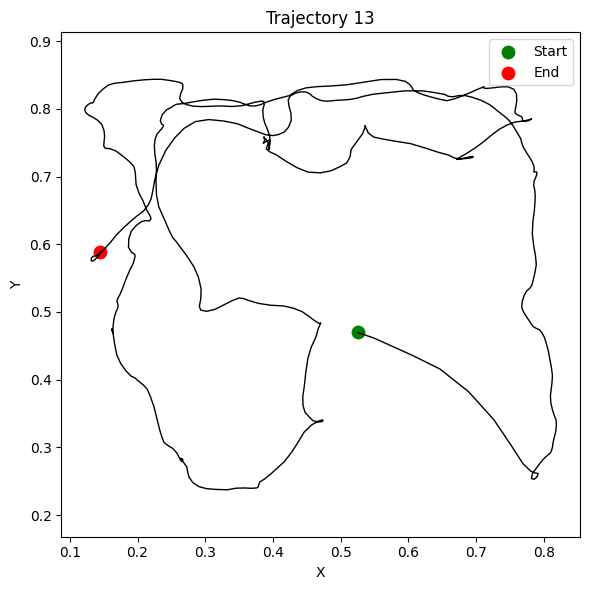

Plotting d1...


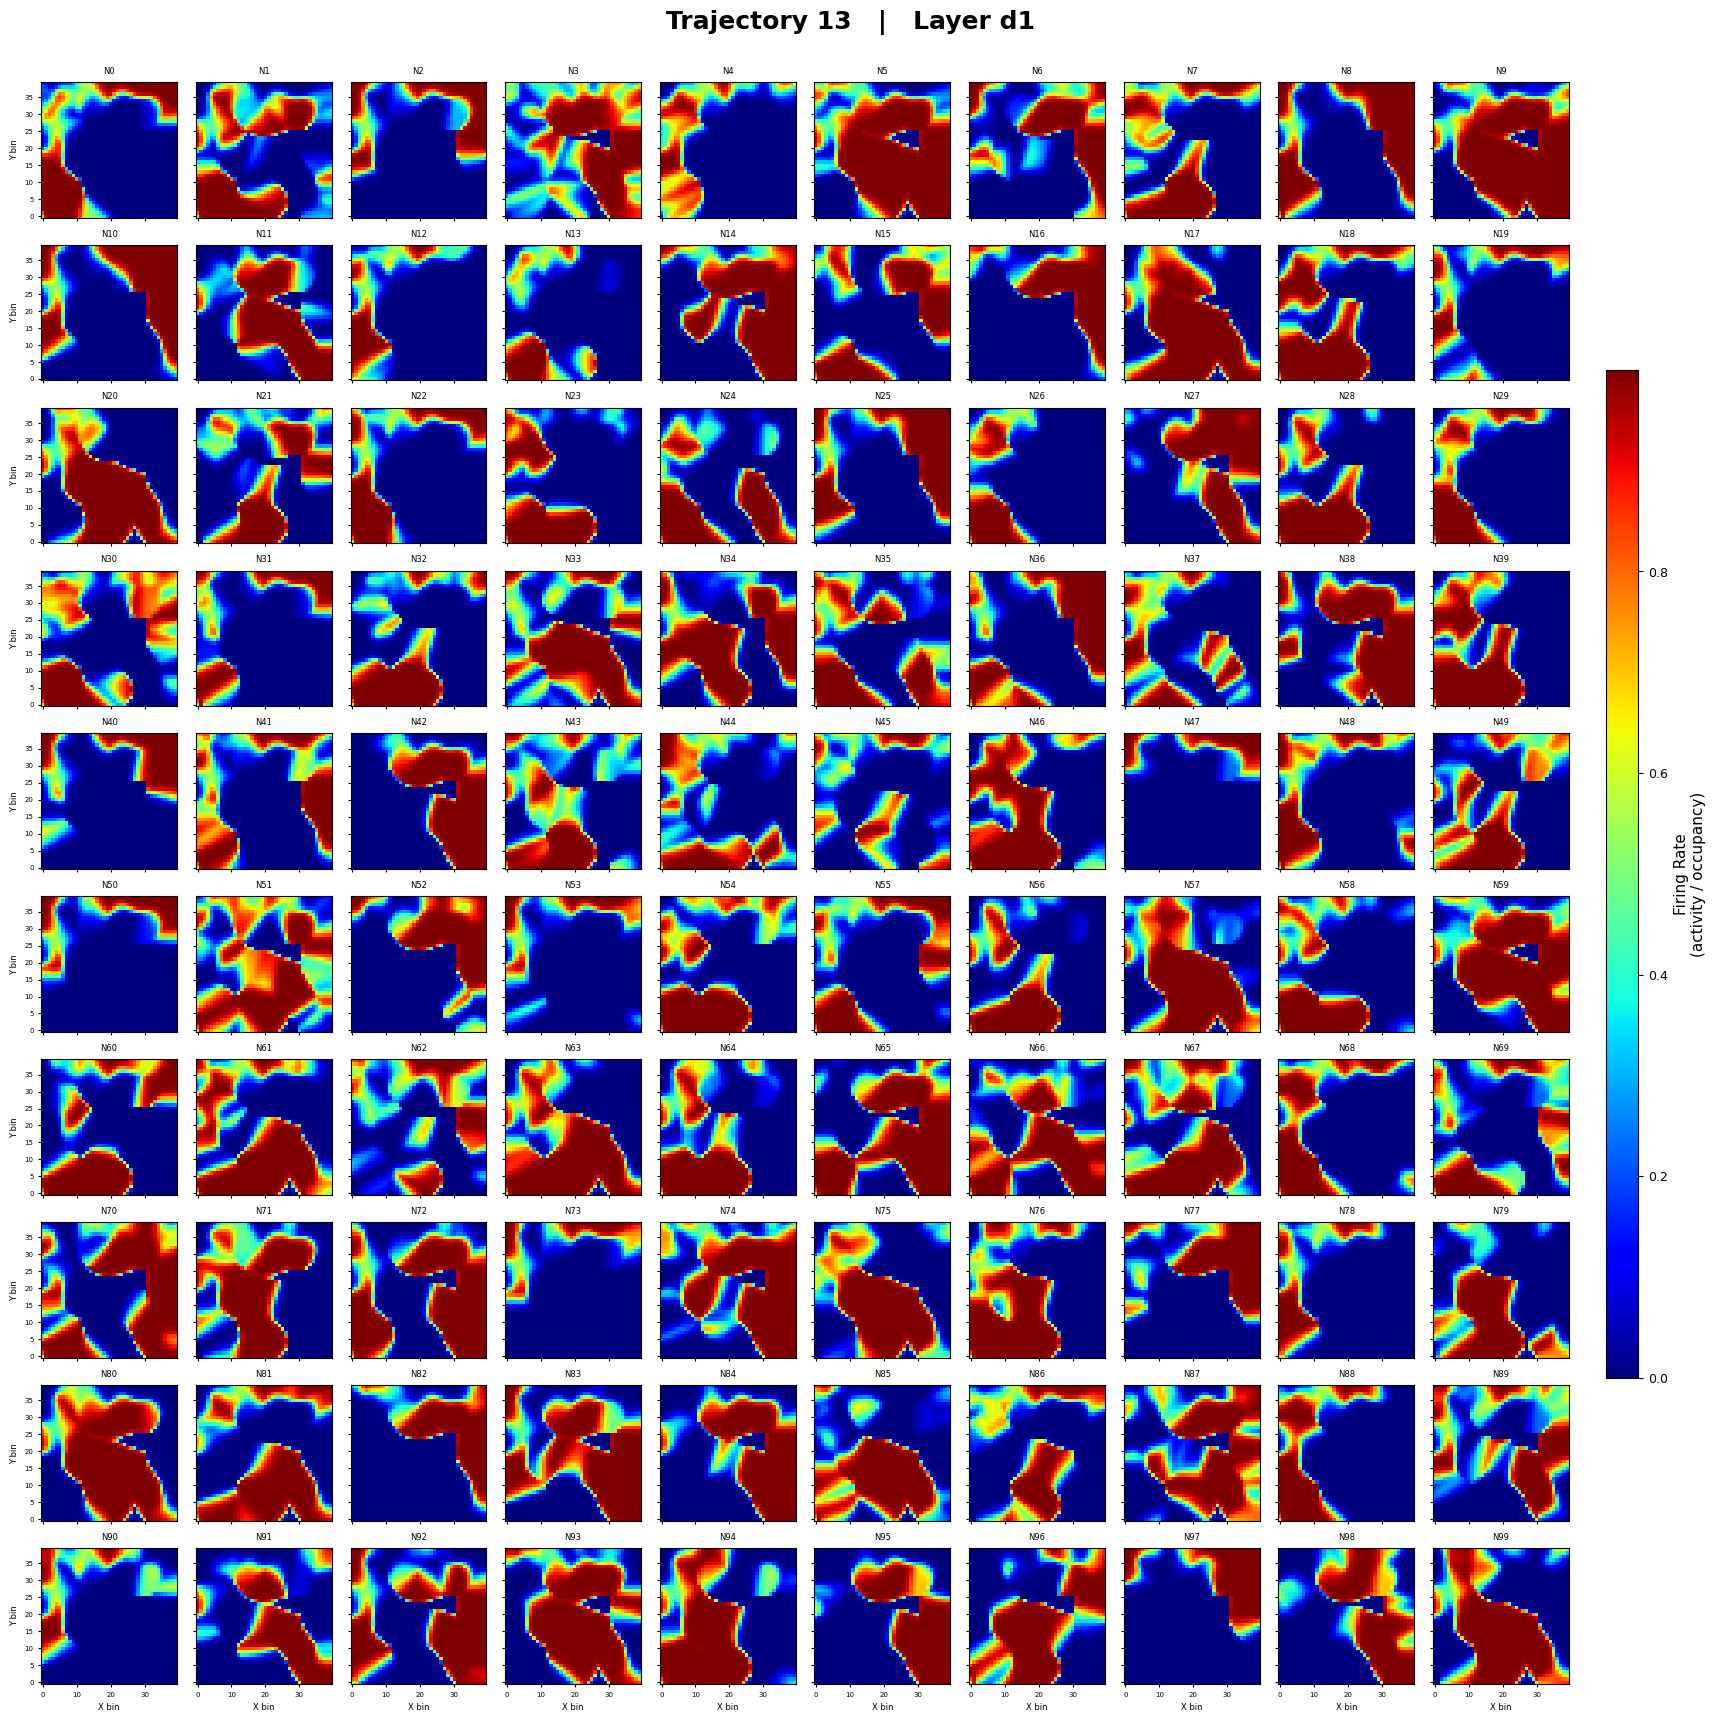

Plotting z1...


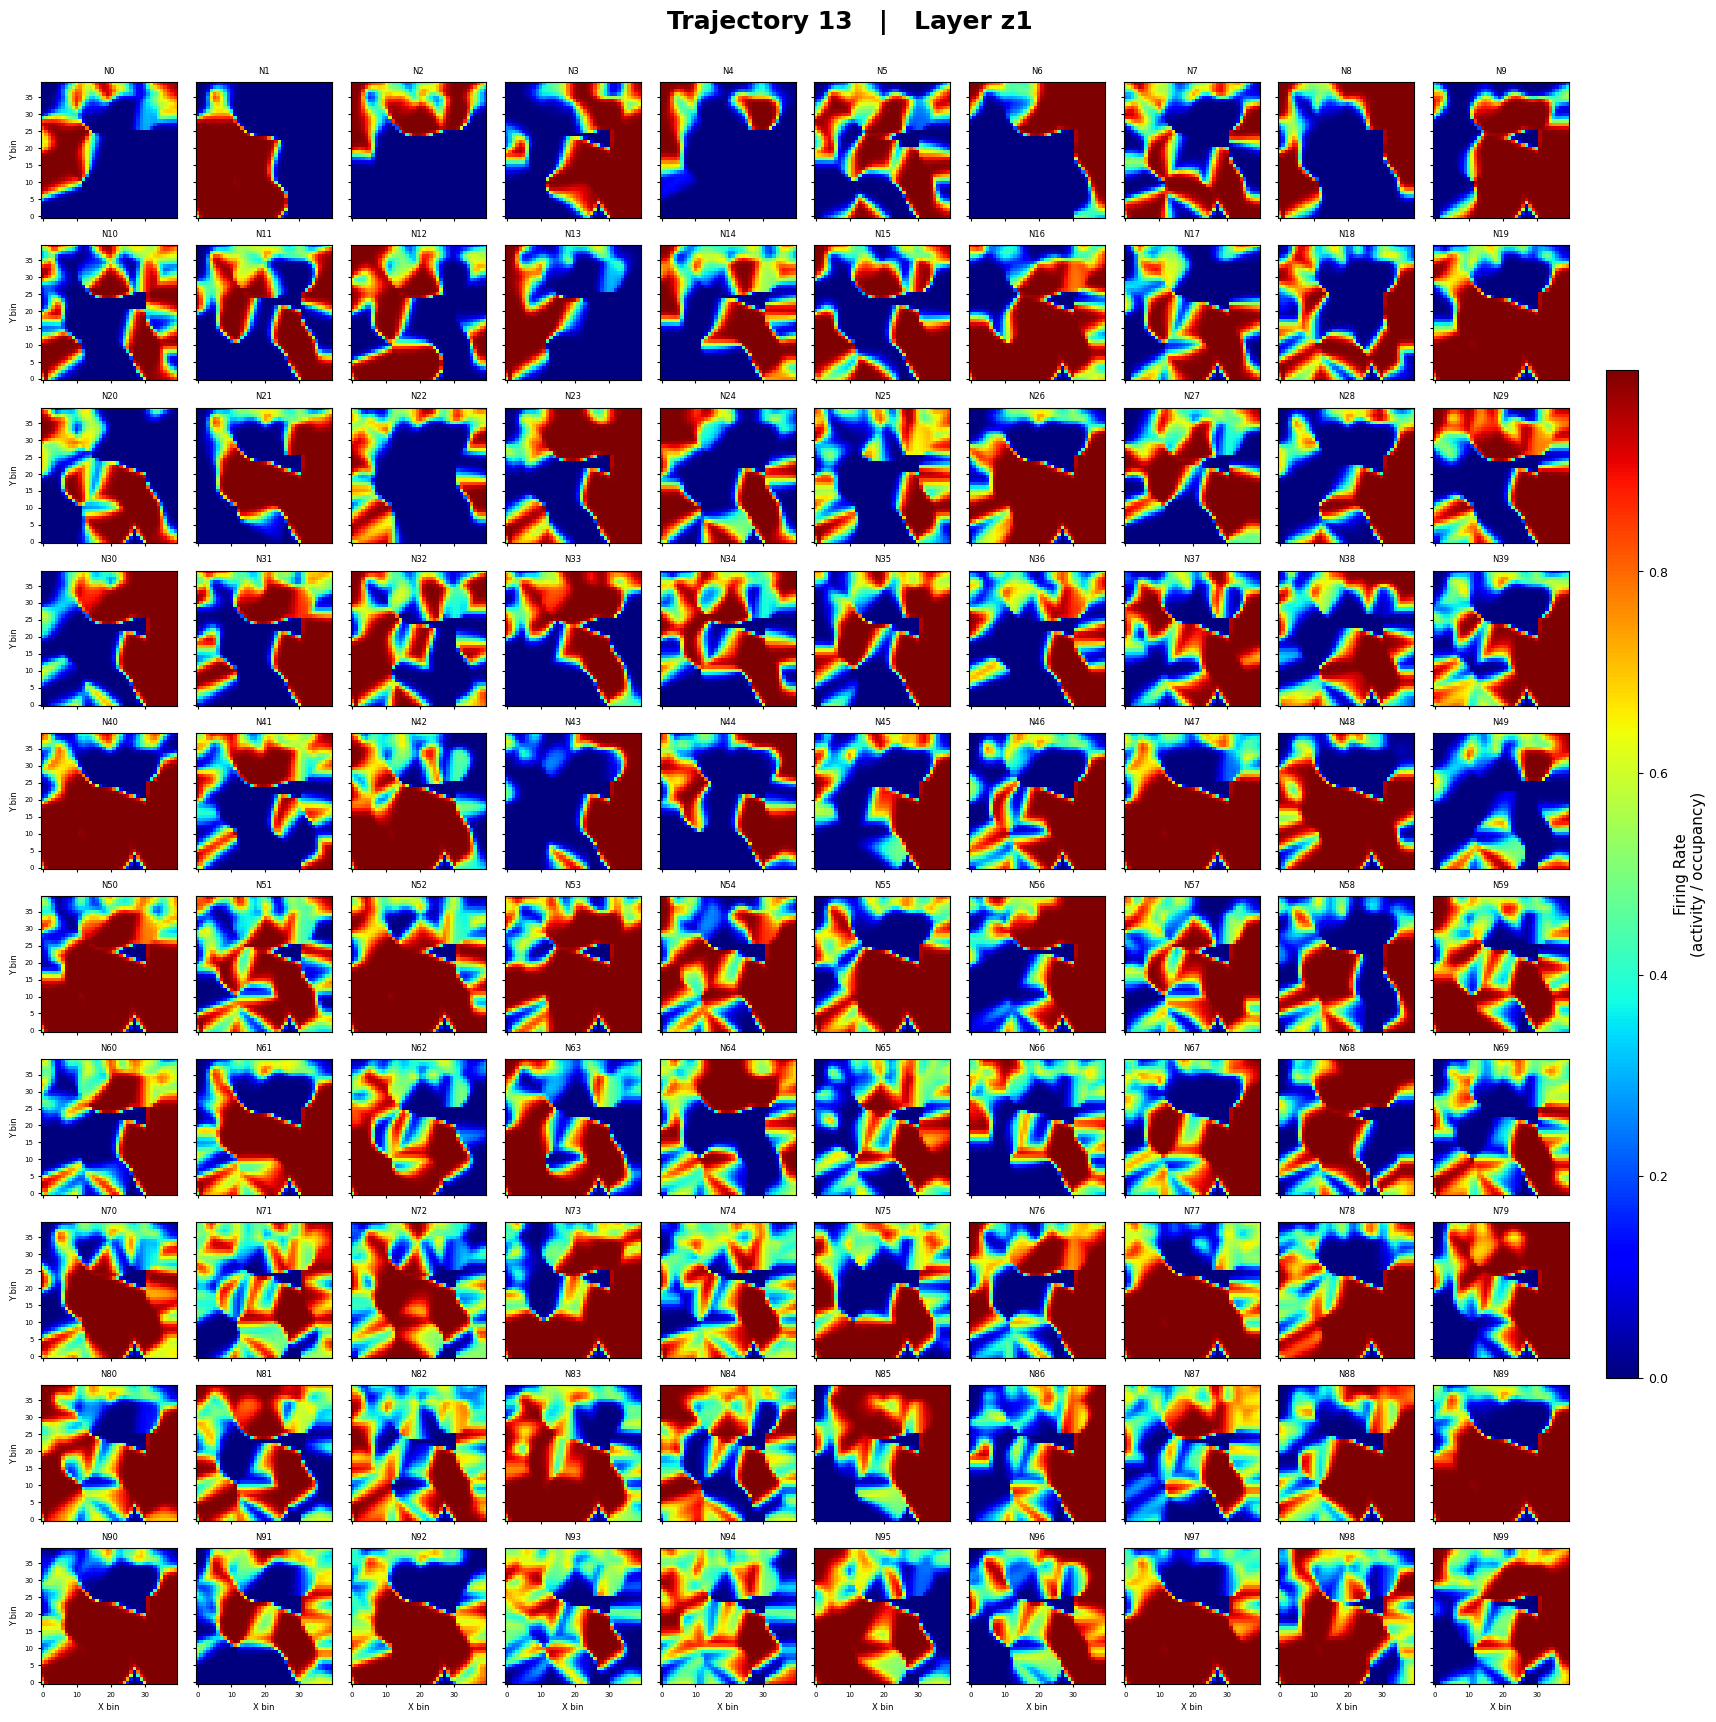

Plotting d2...


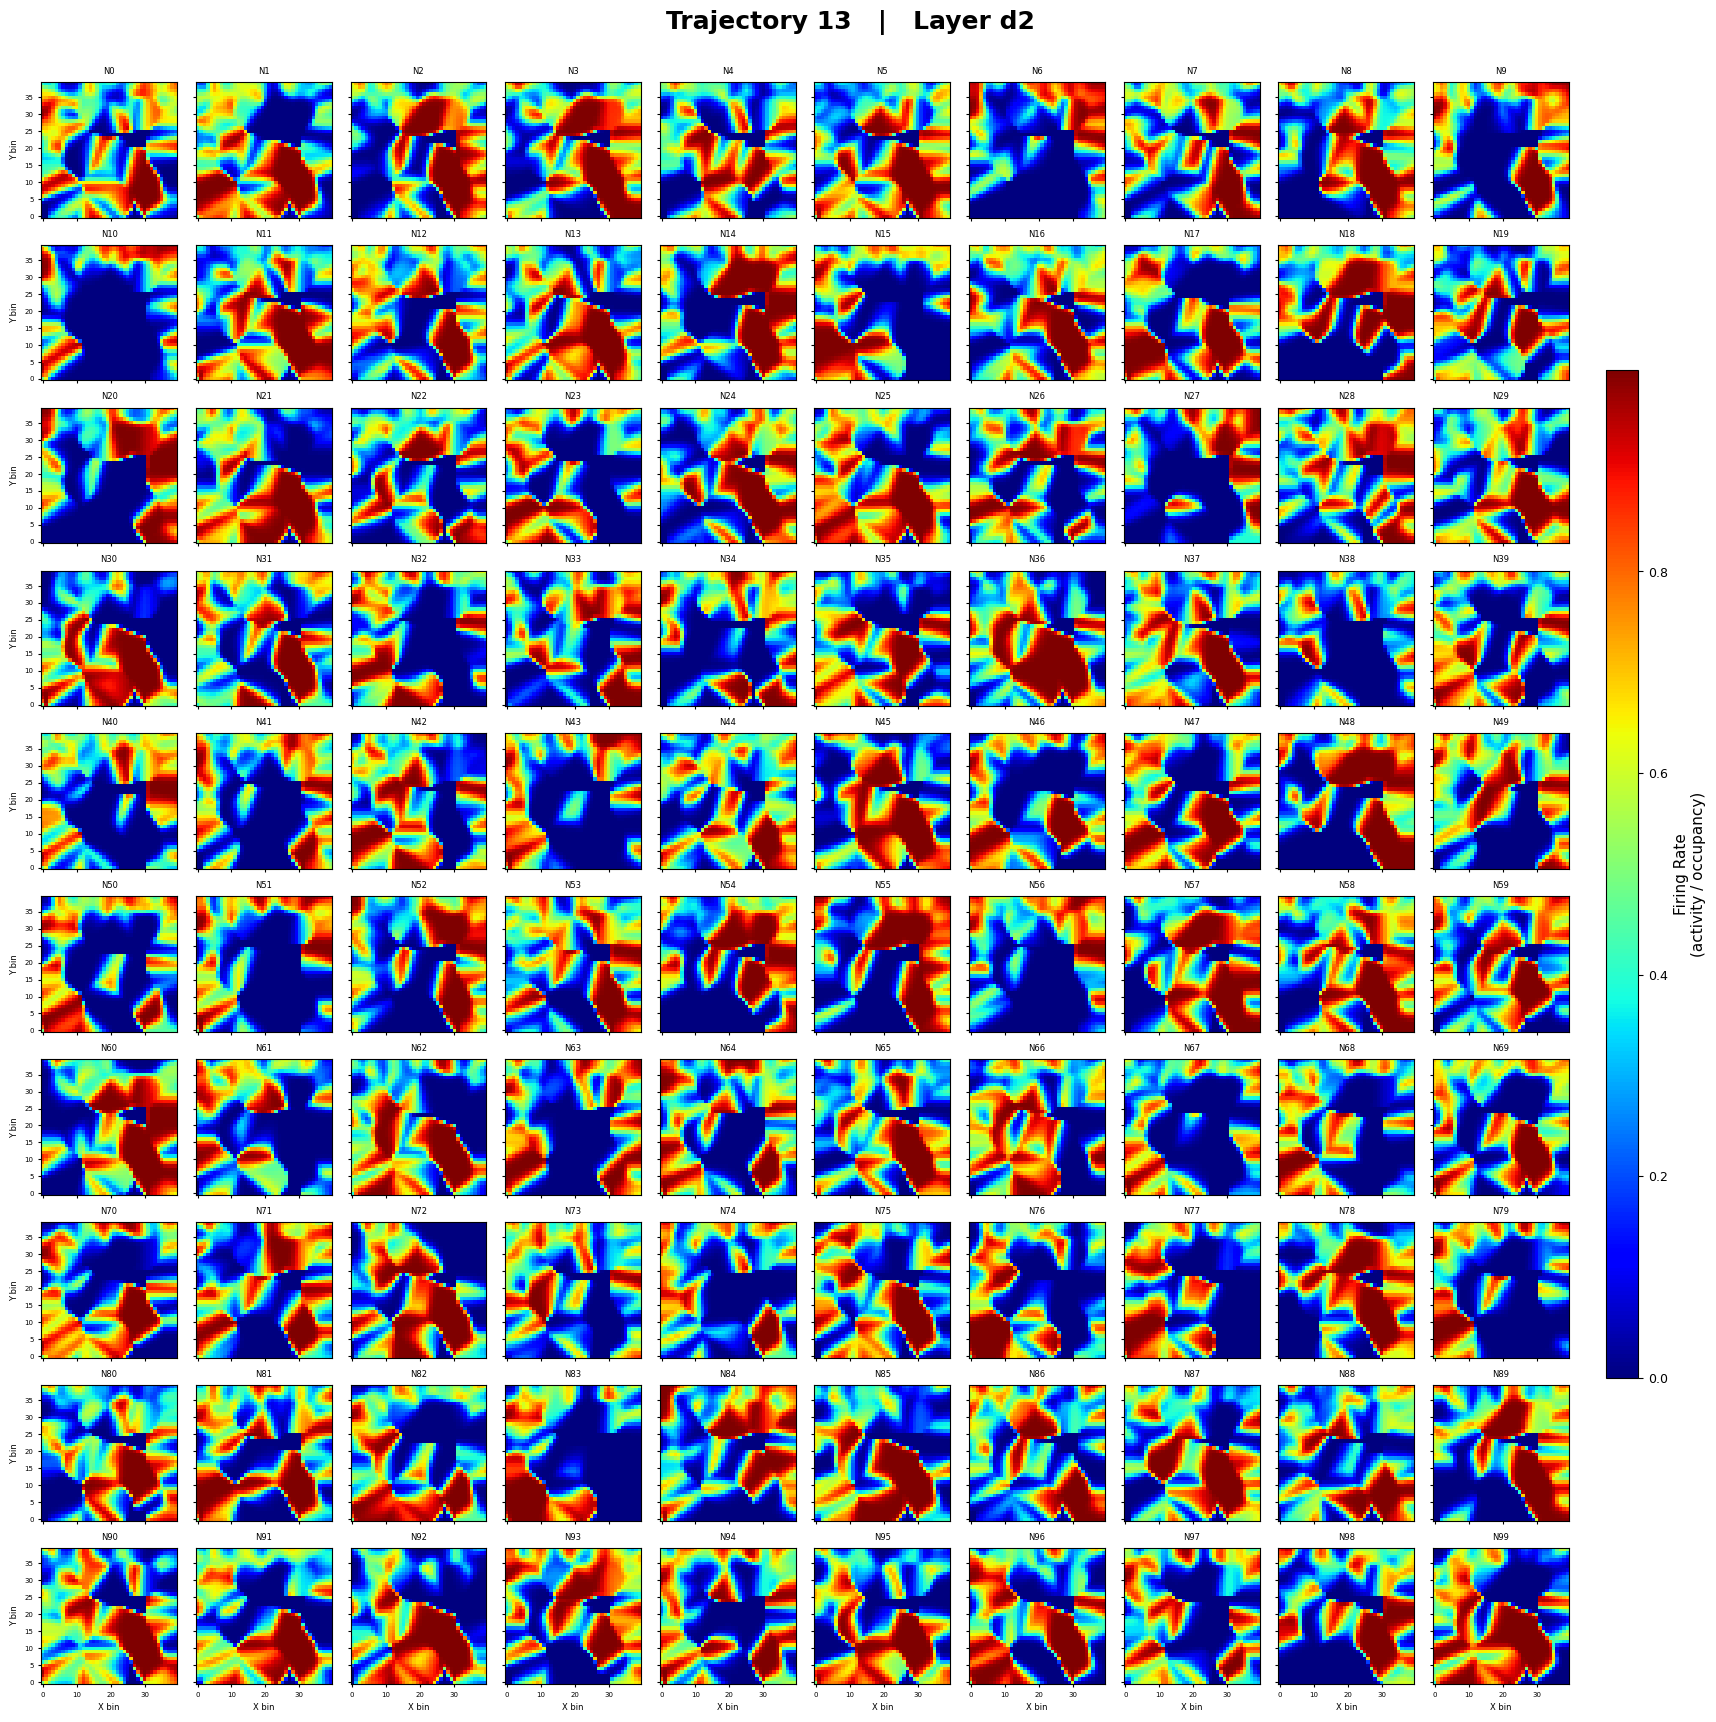

Plotting z2...


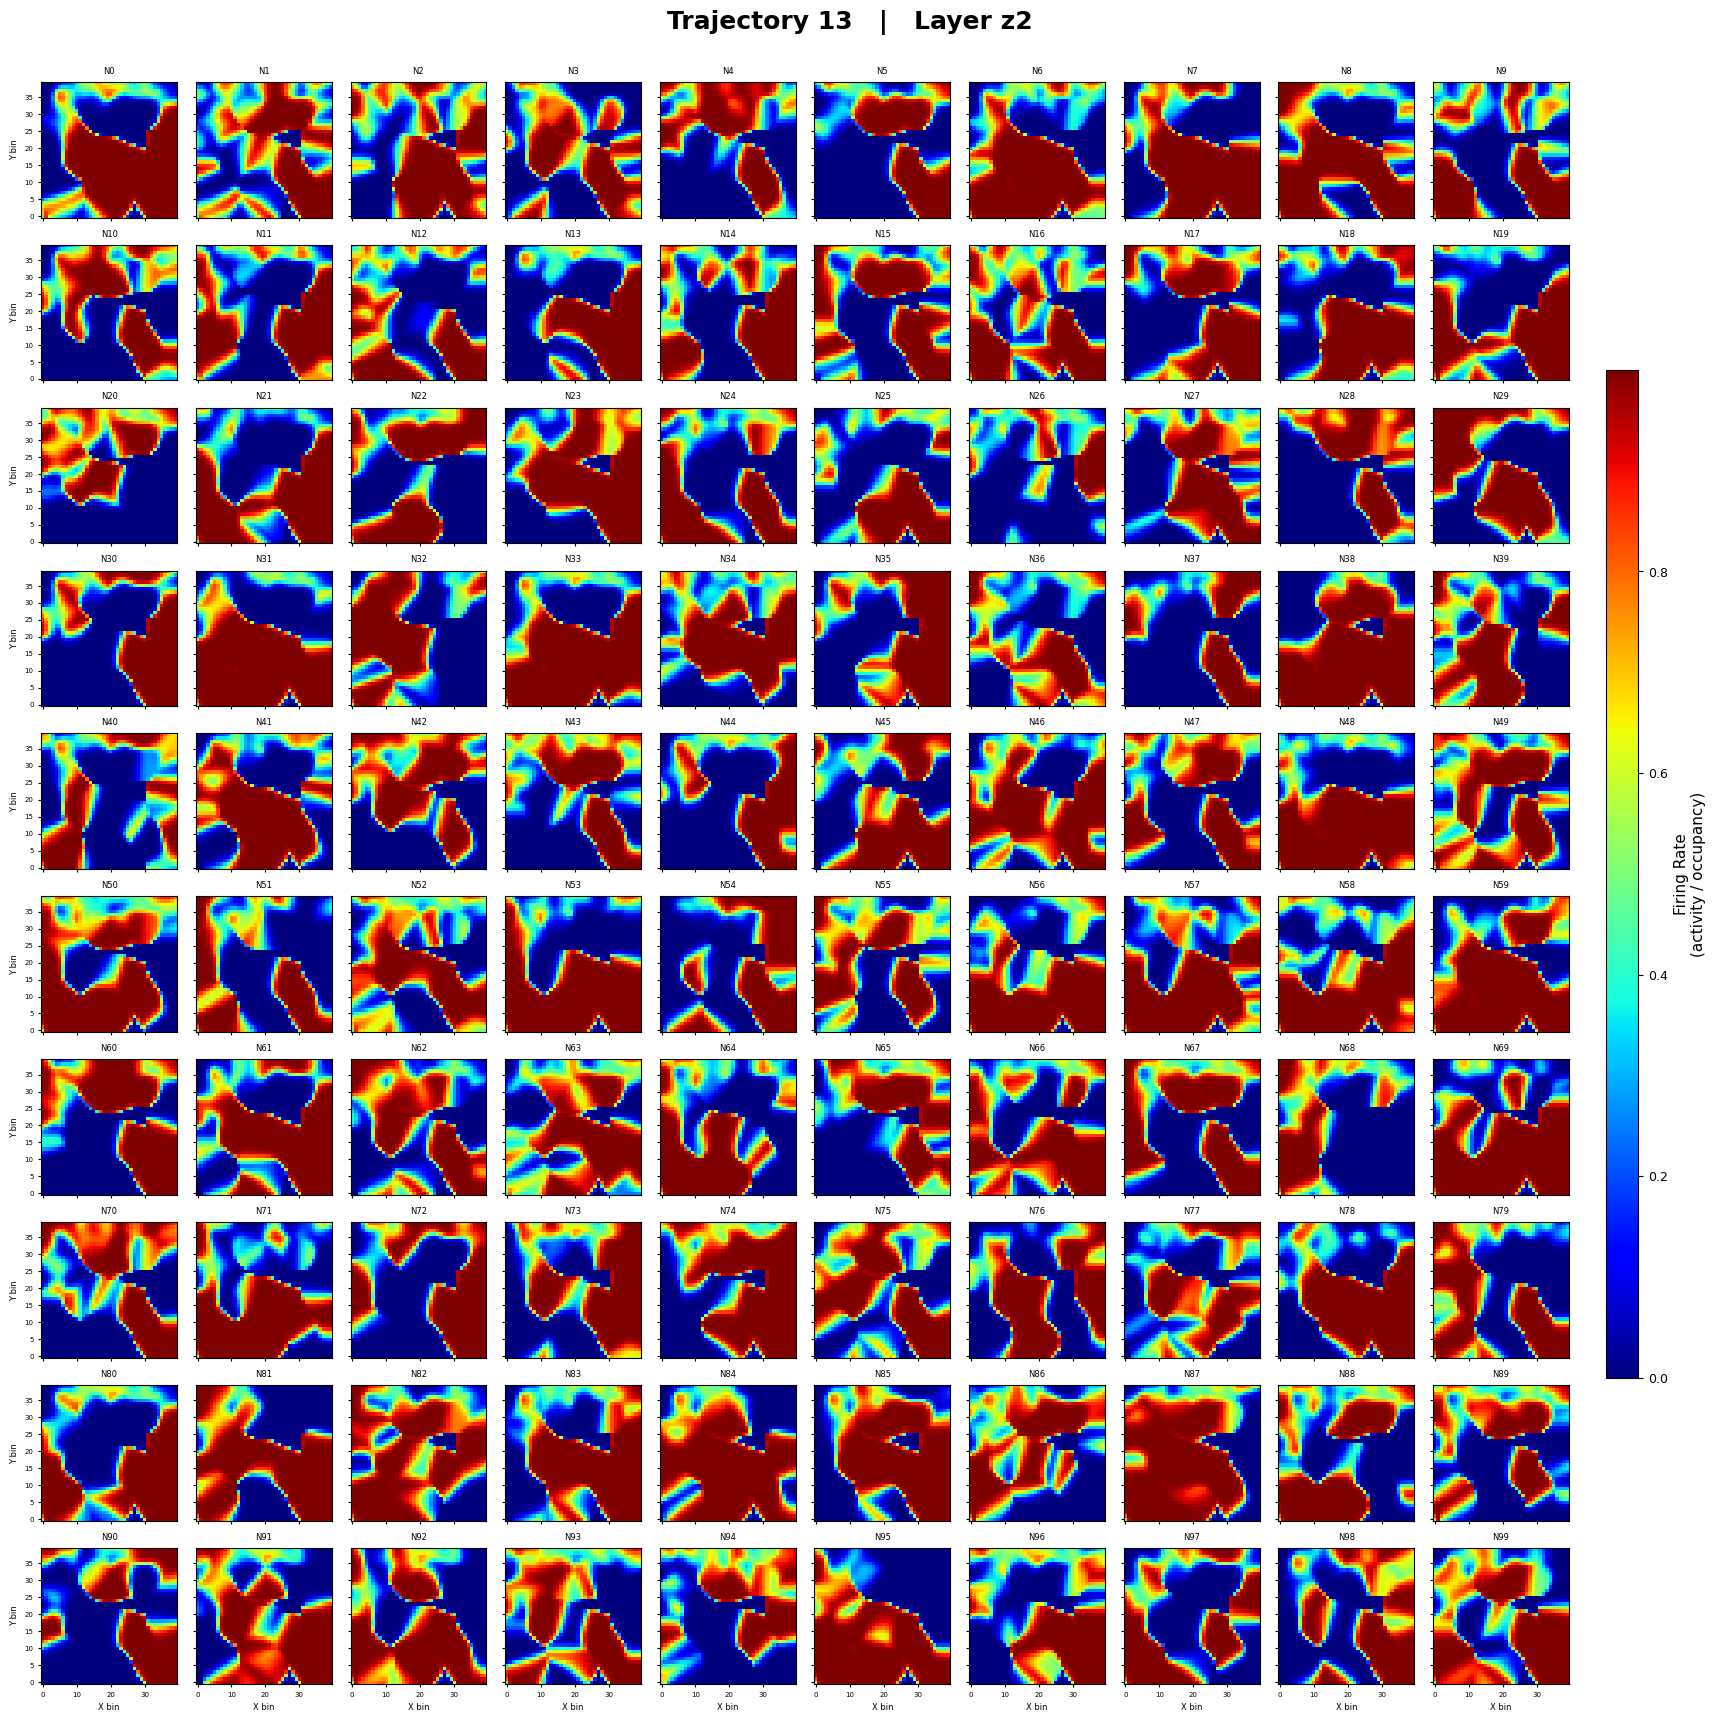

Plotting d3...


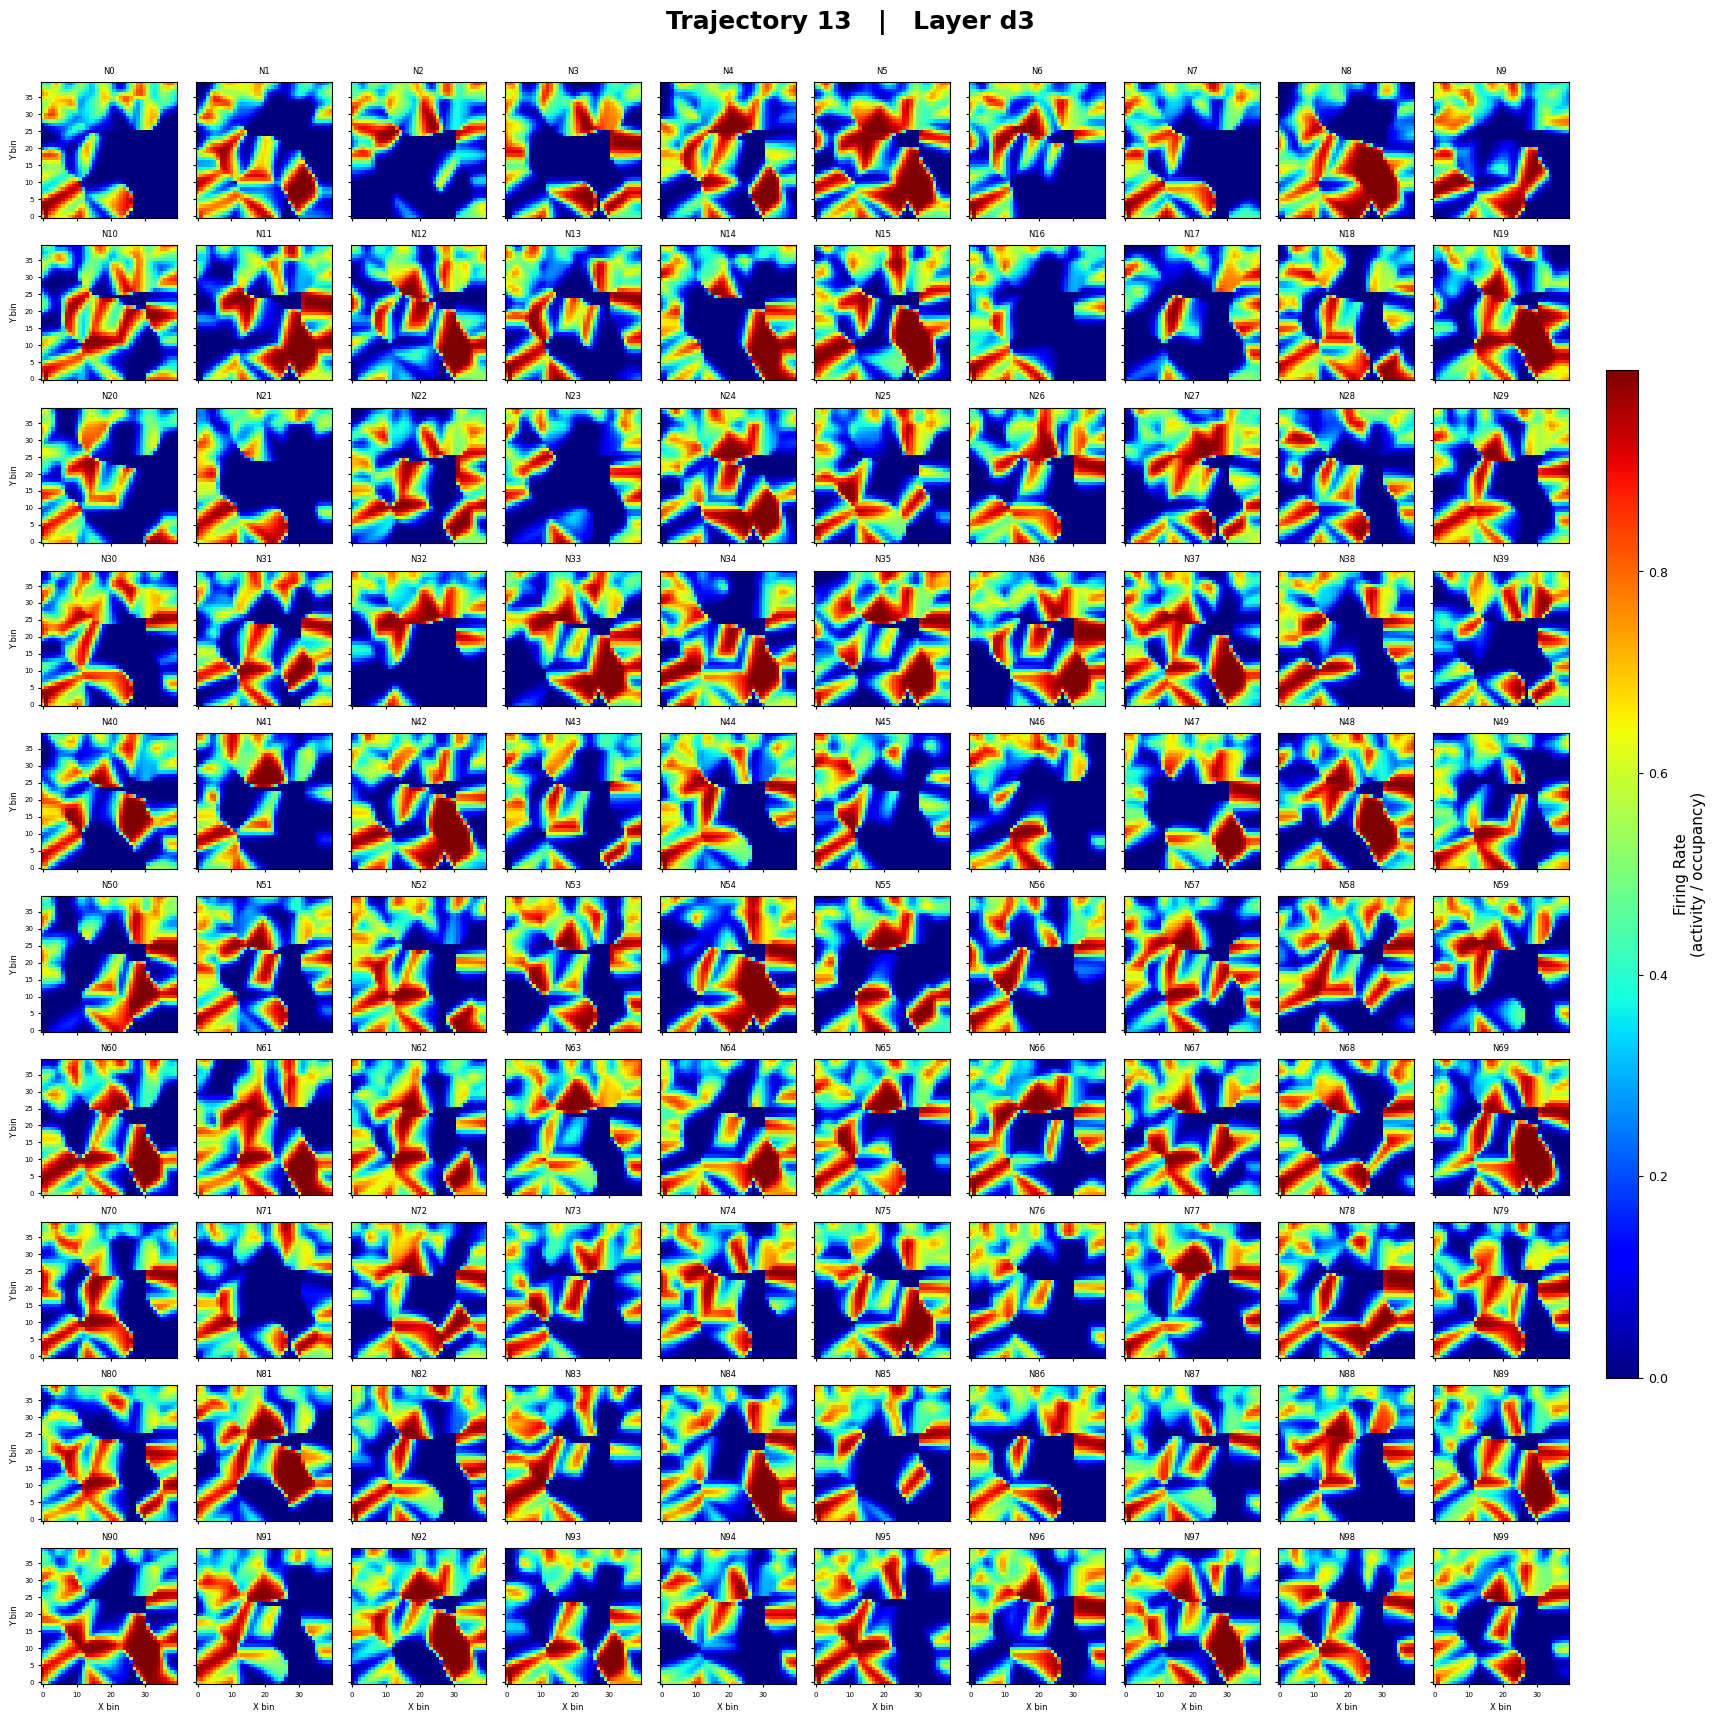

Plotting z3...


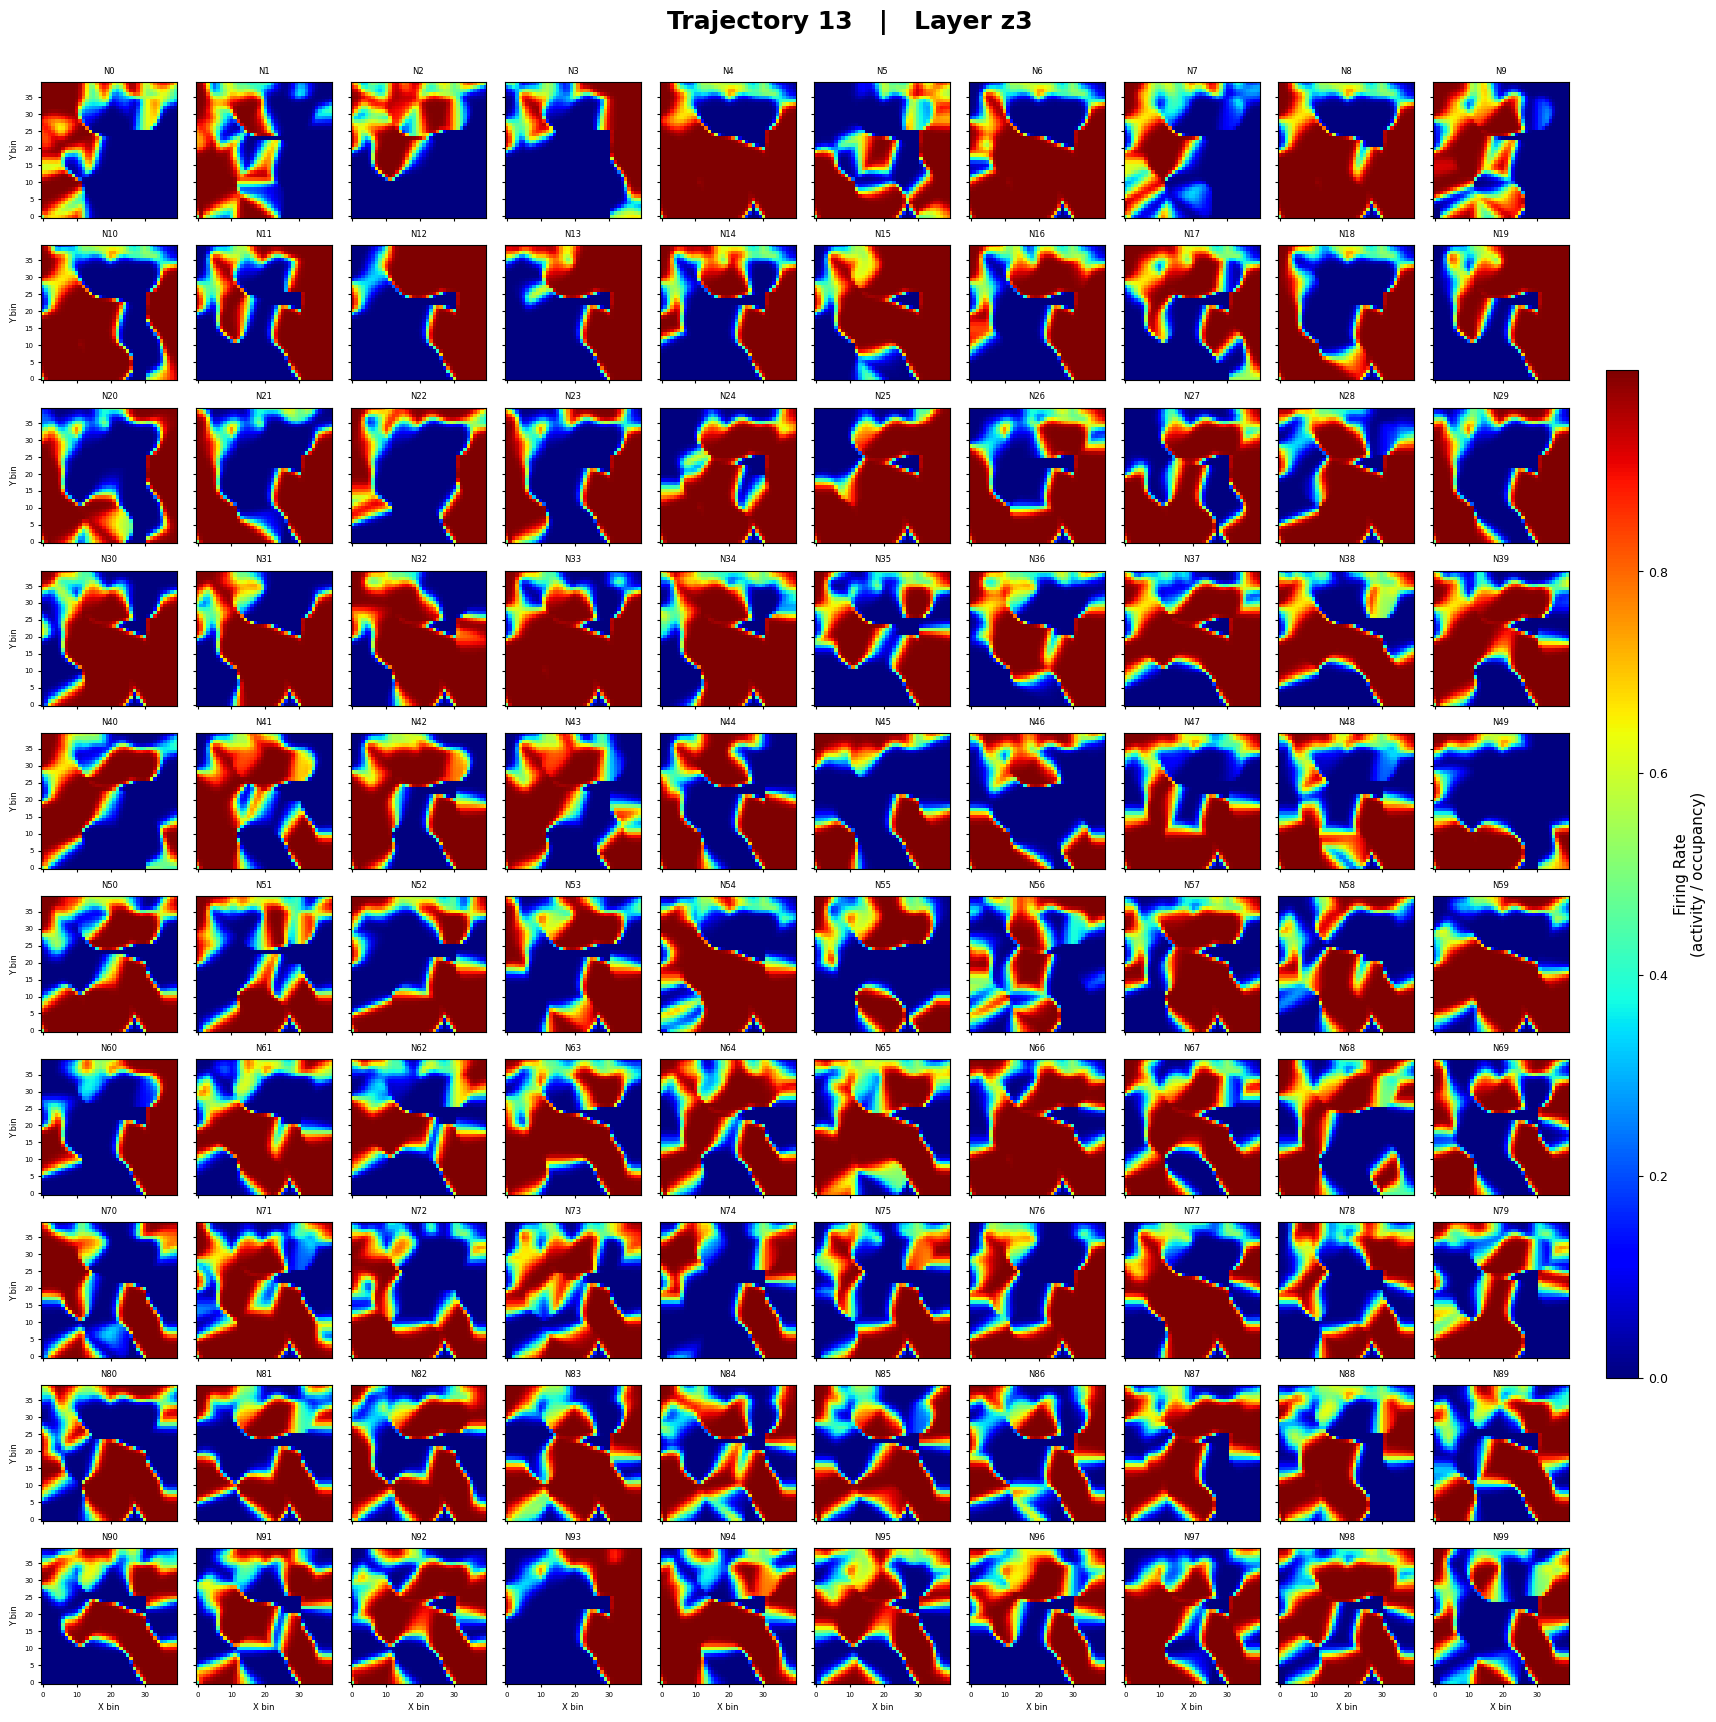

Plotting d4...


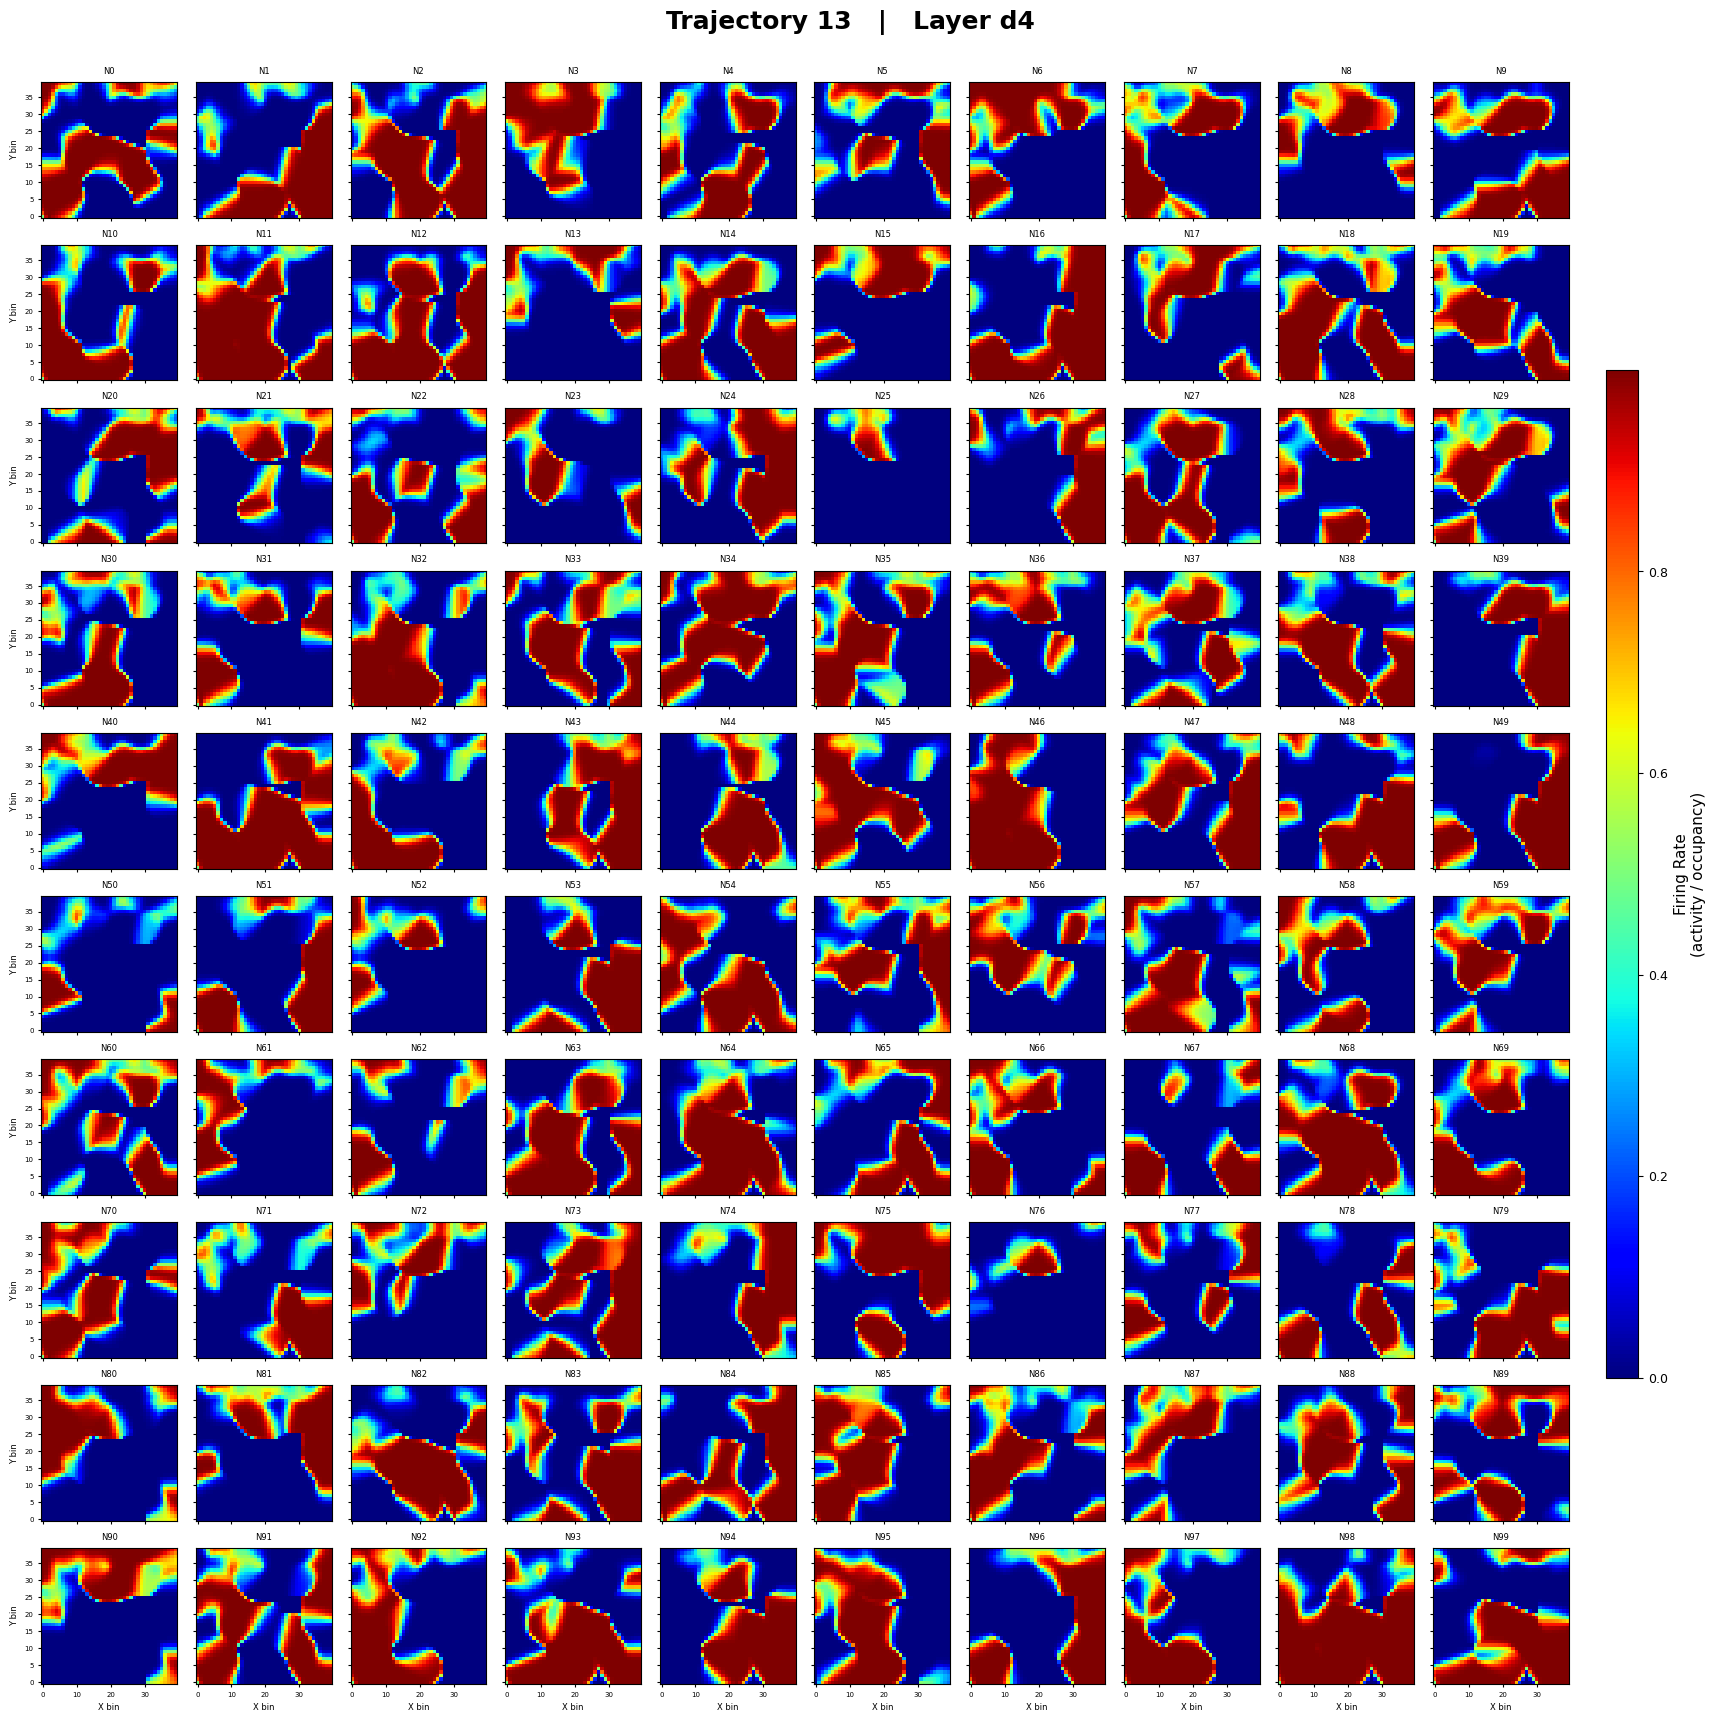



Trajectory 39


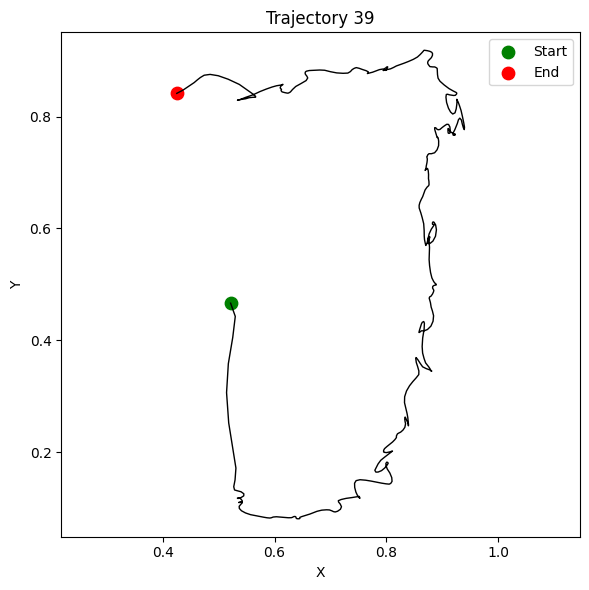

Plotting d1...


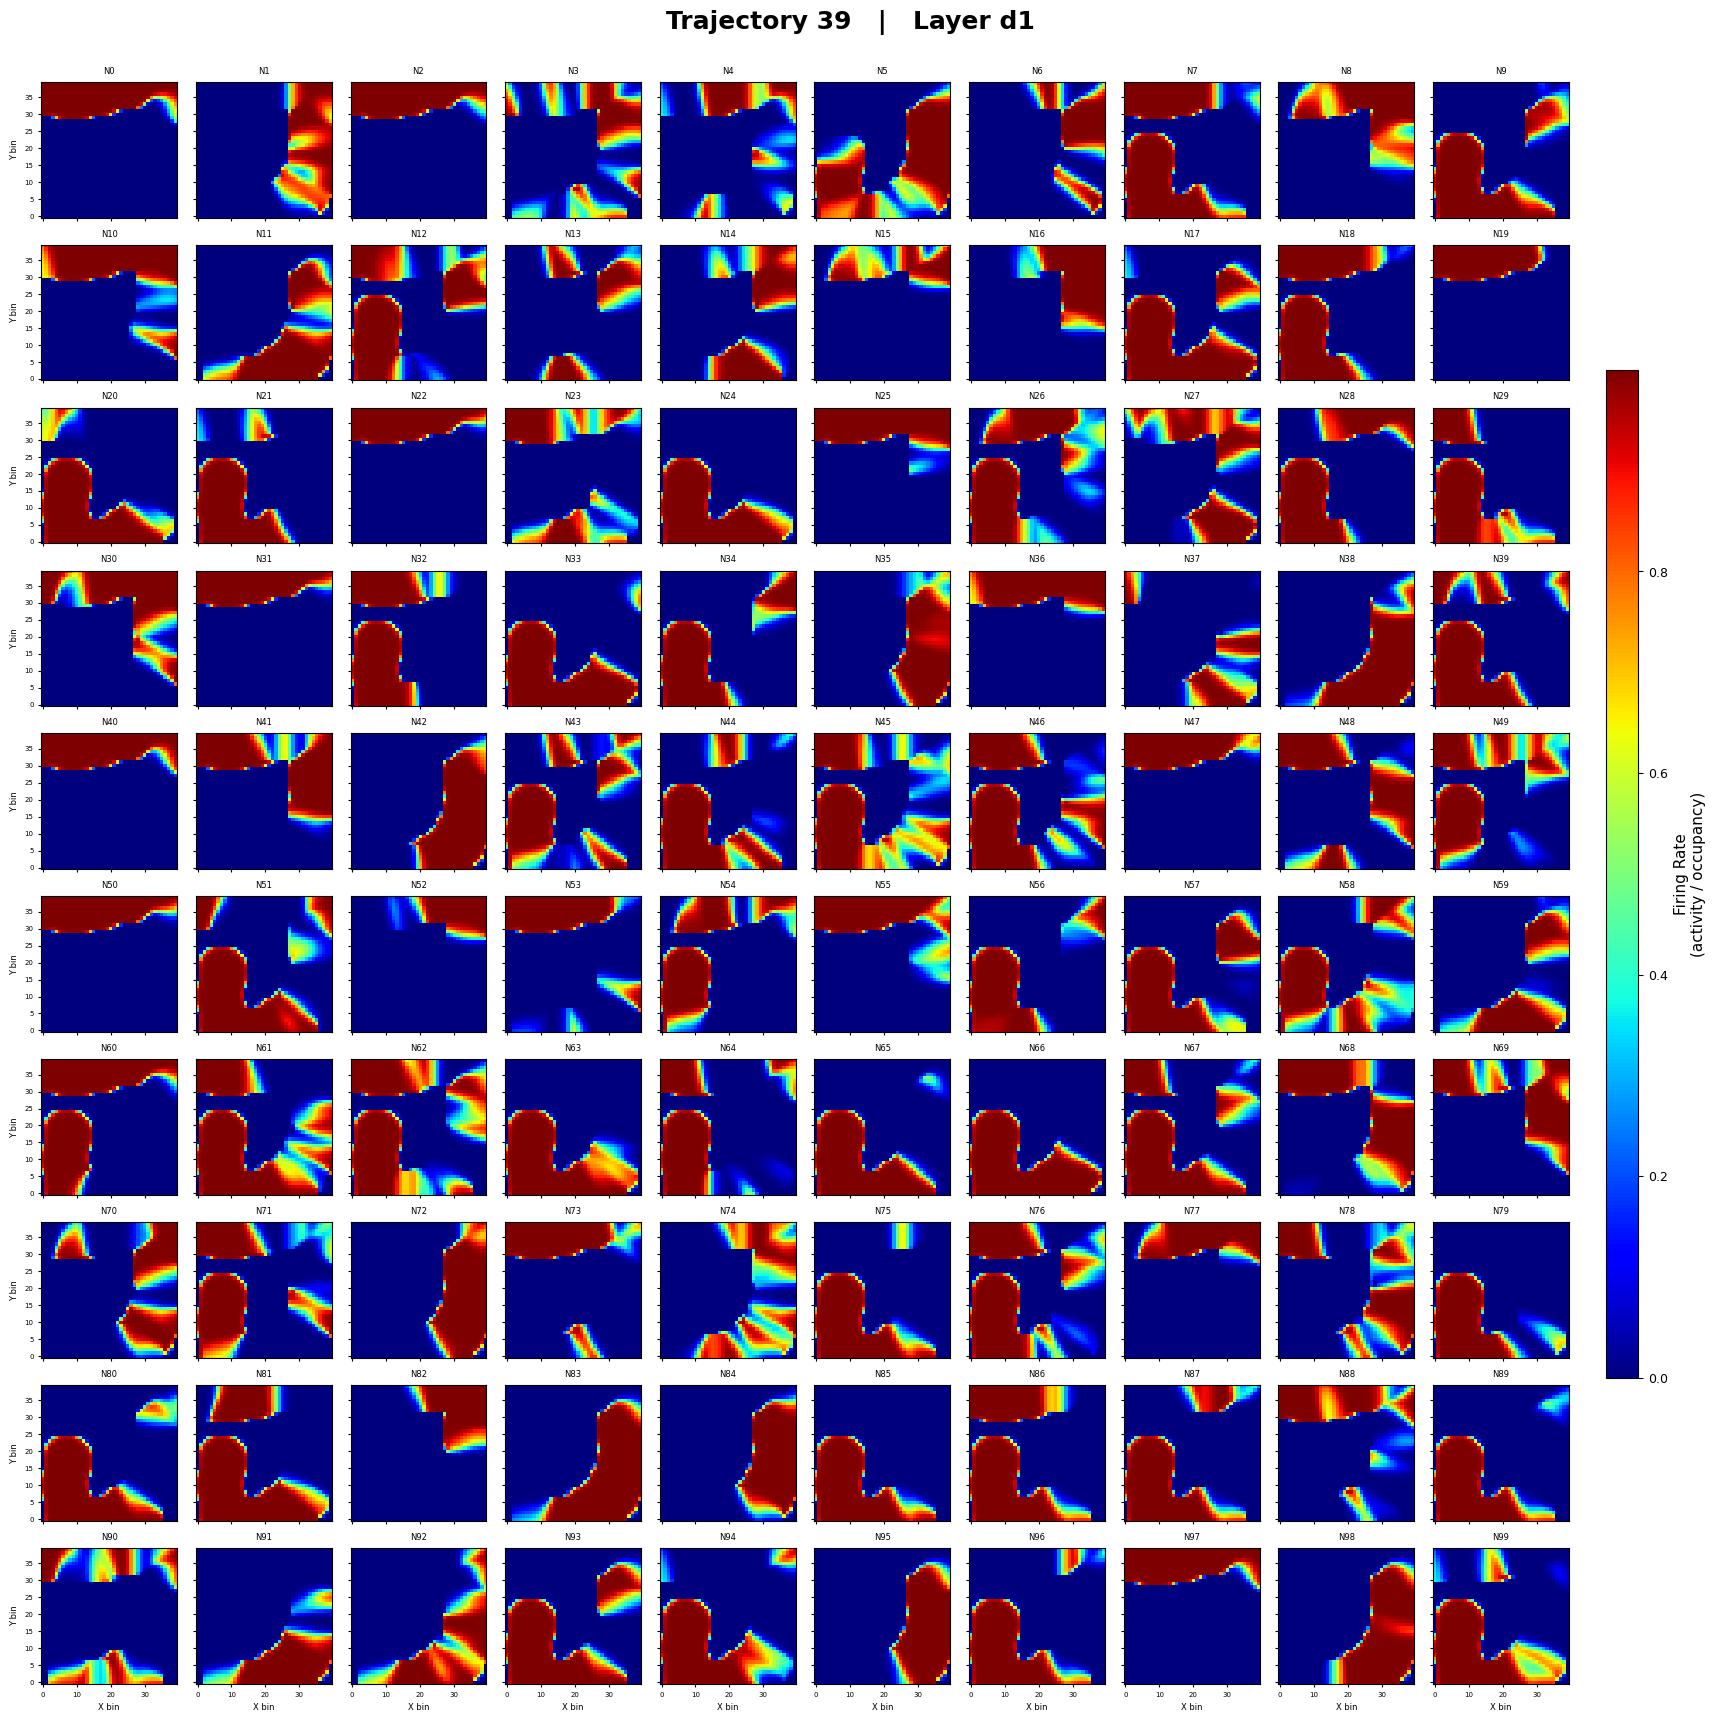

Plotting z1...


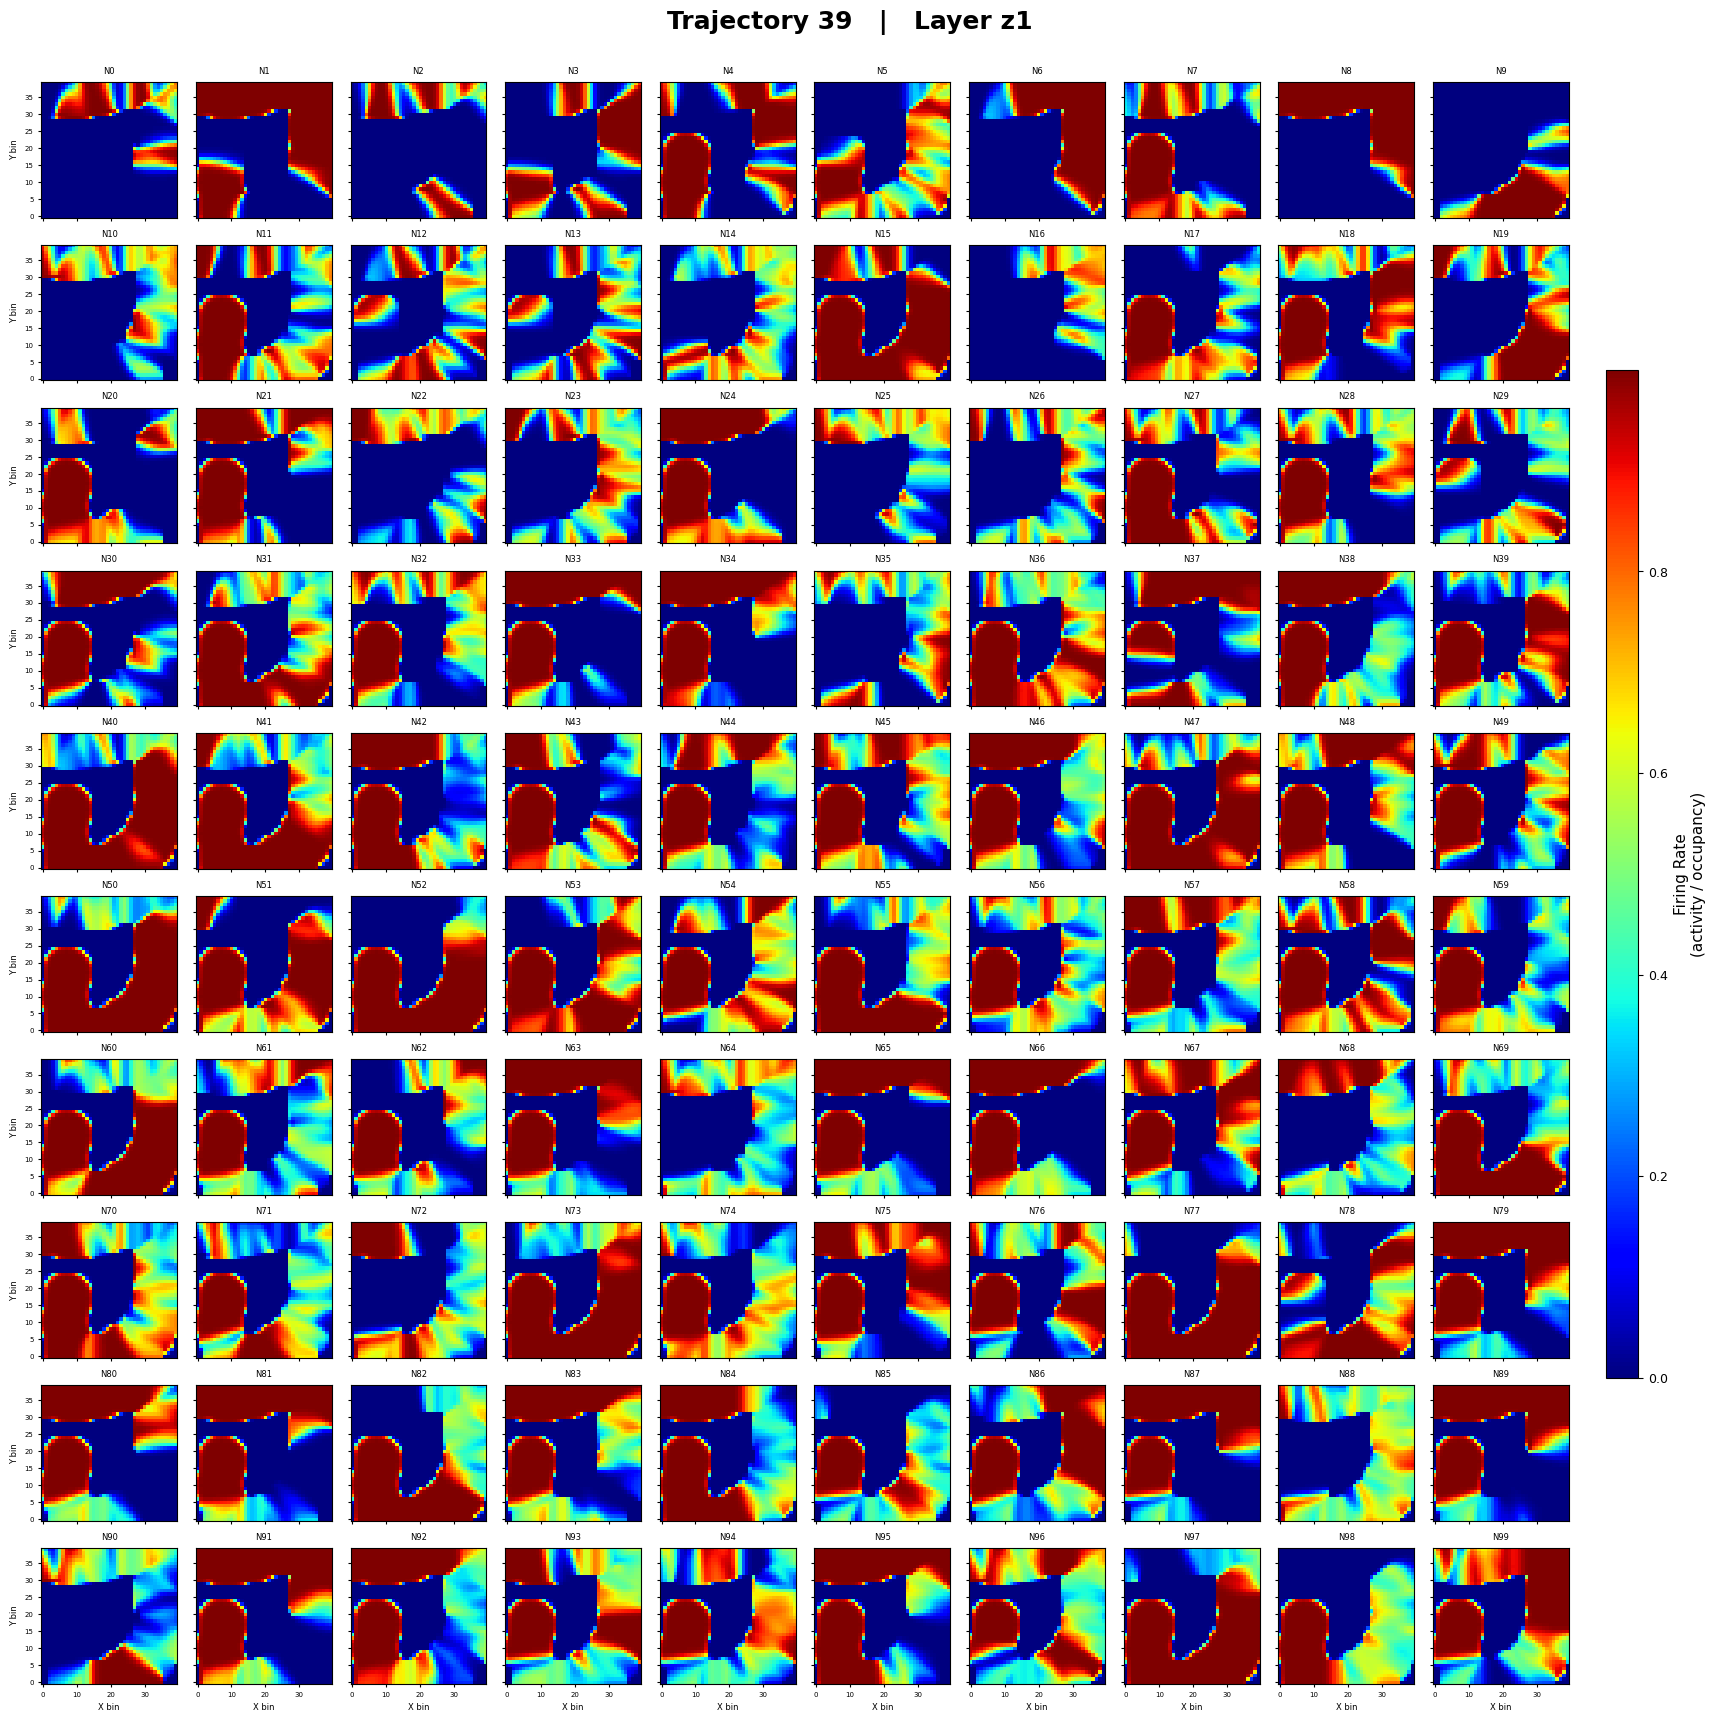

Plotting d2...


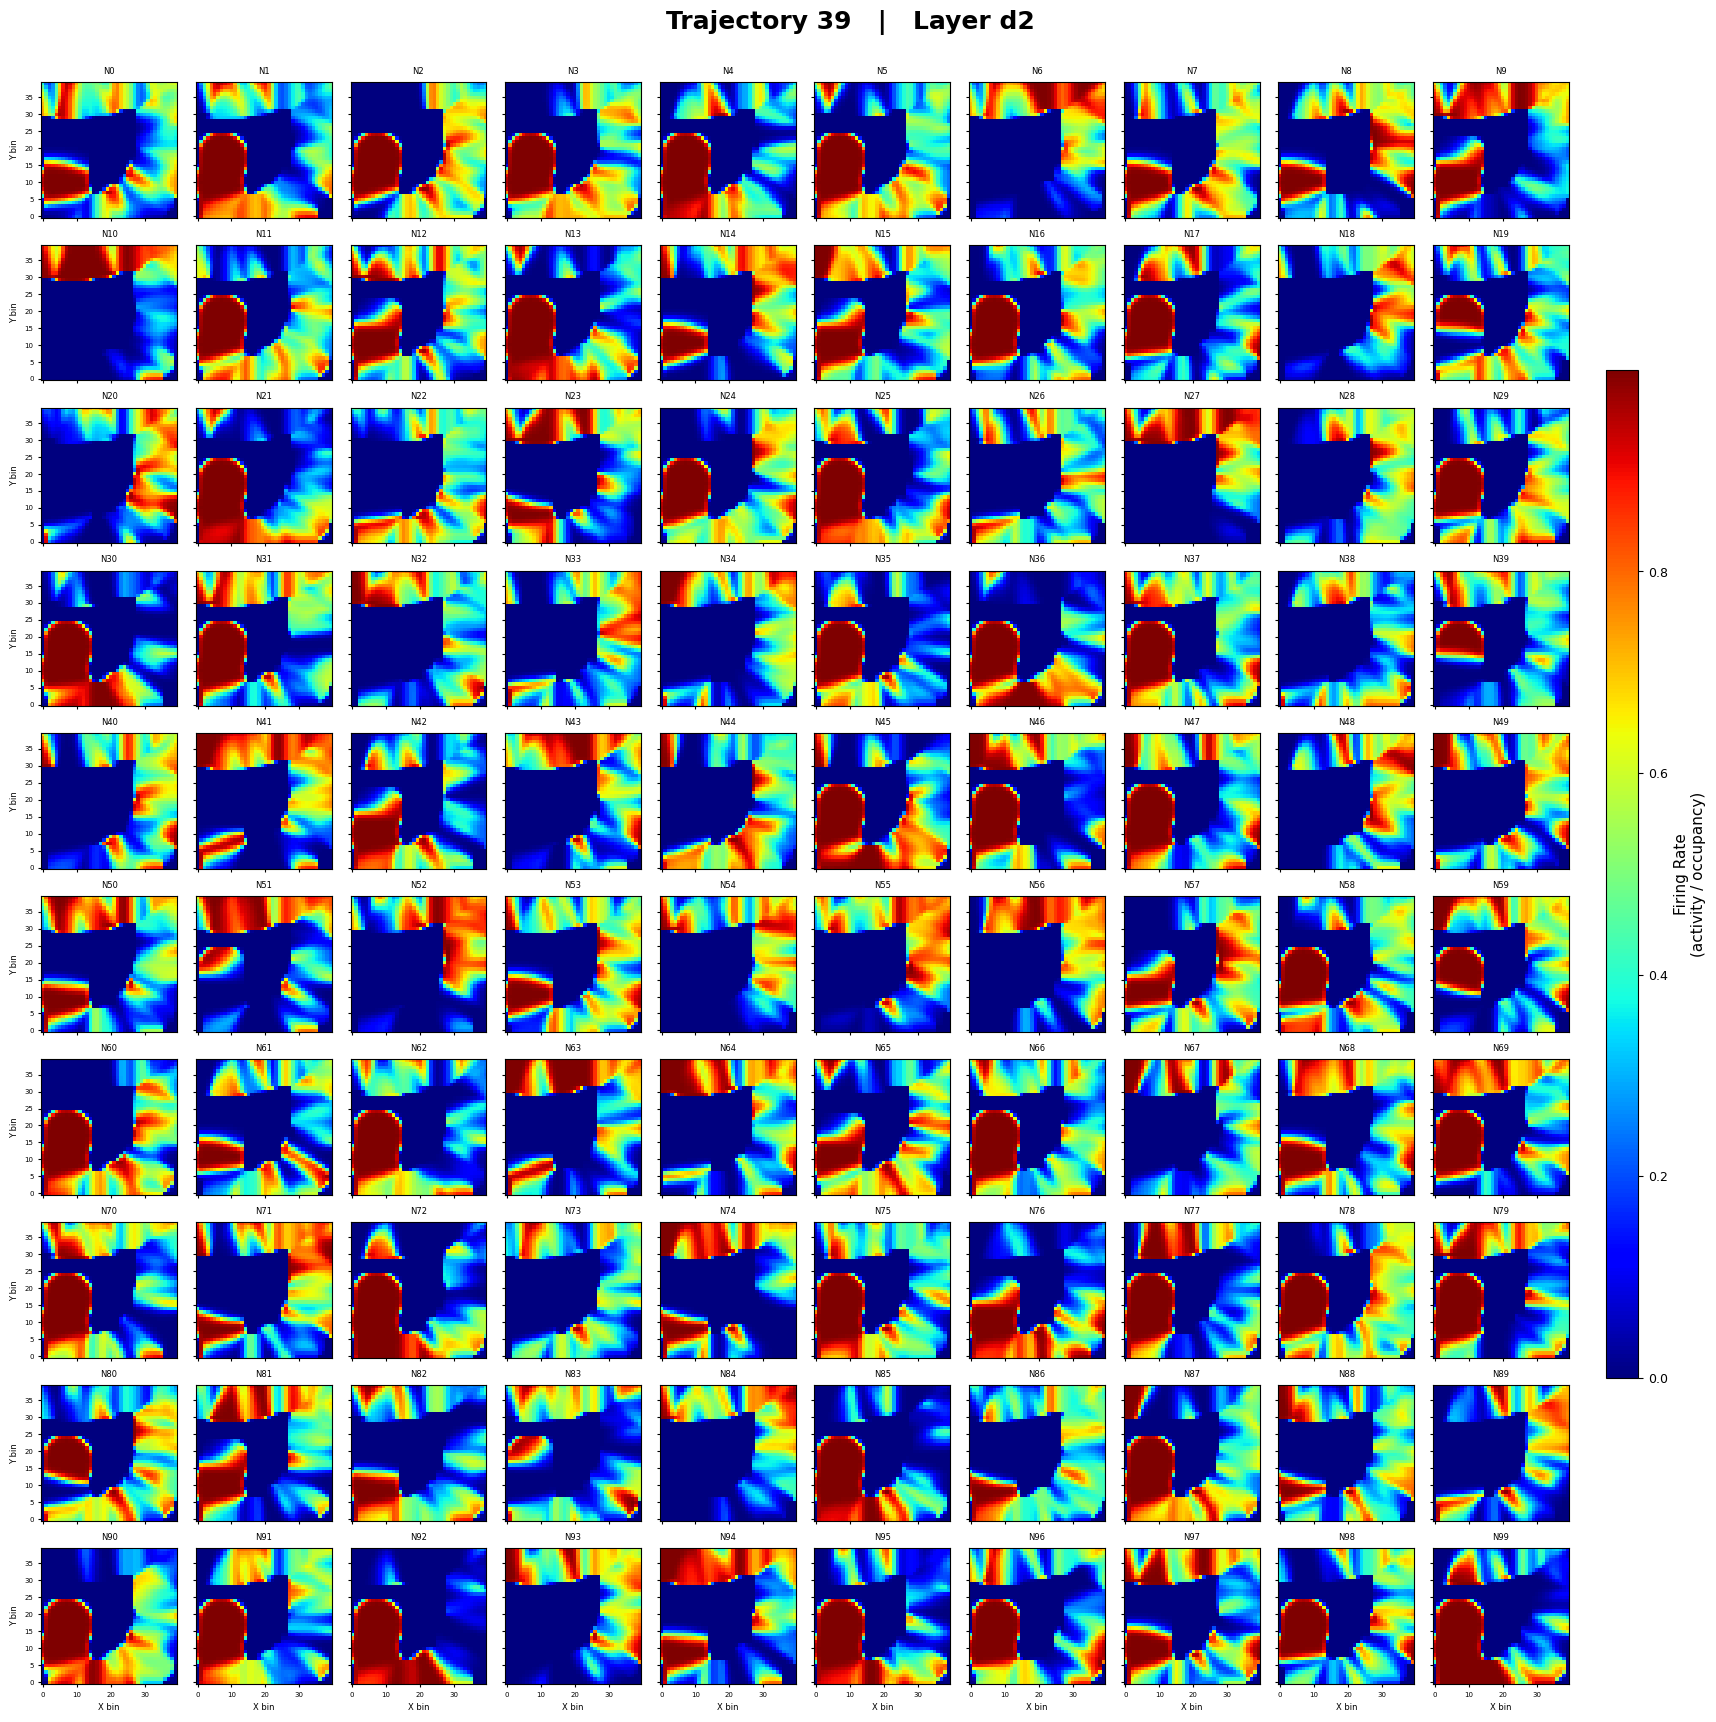

Plotting z2...


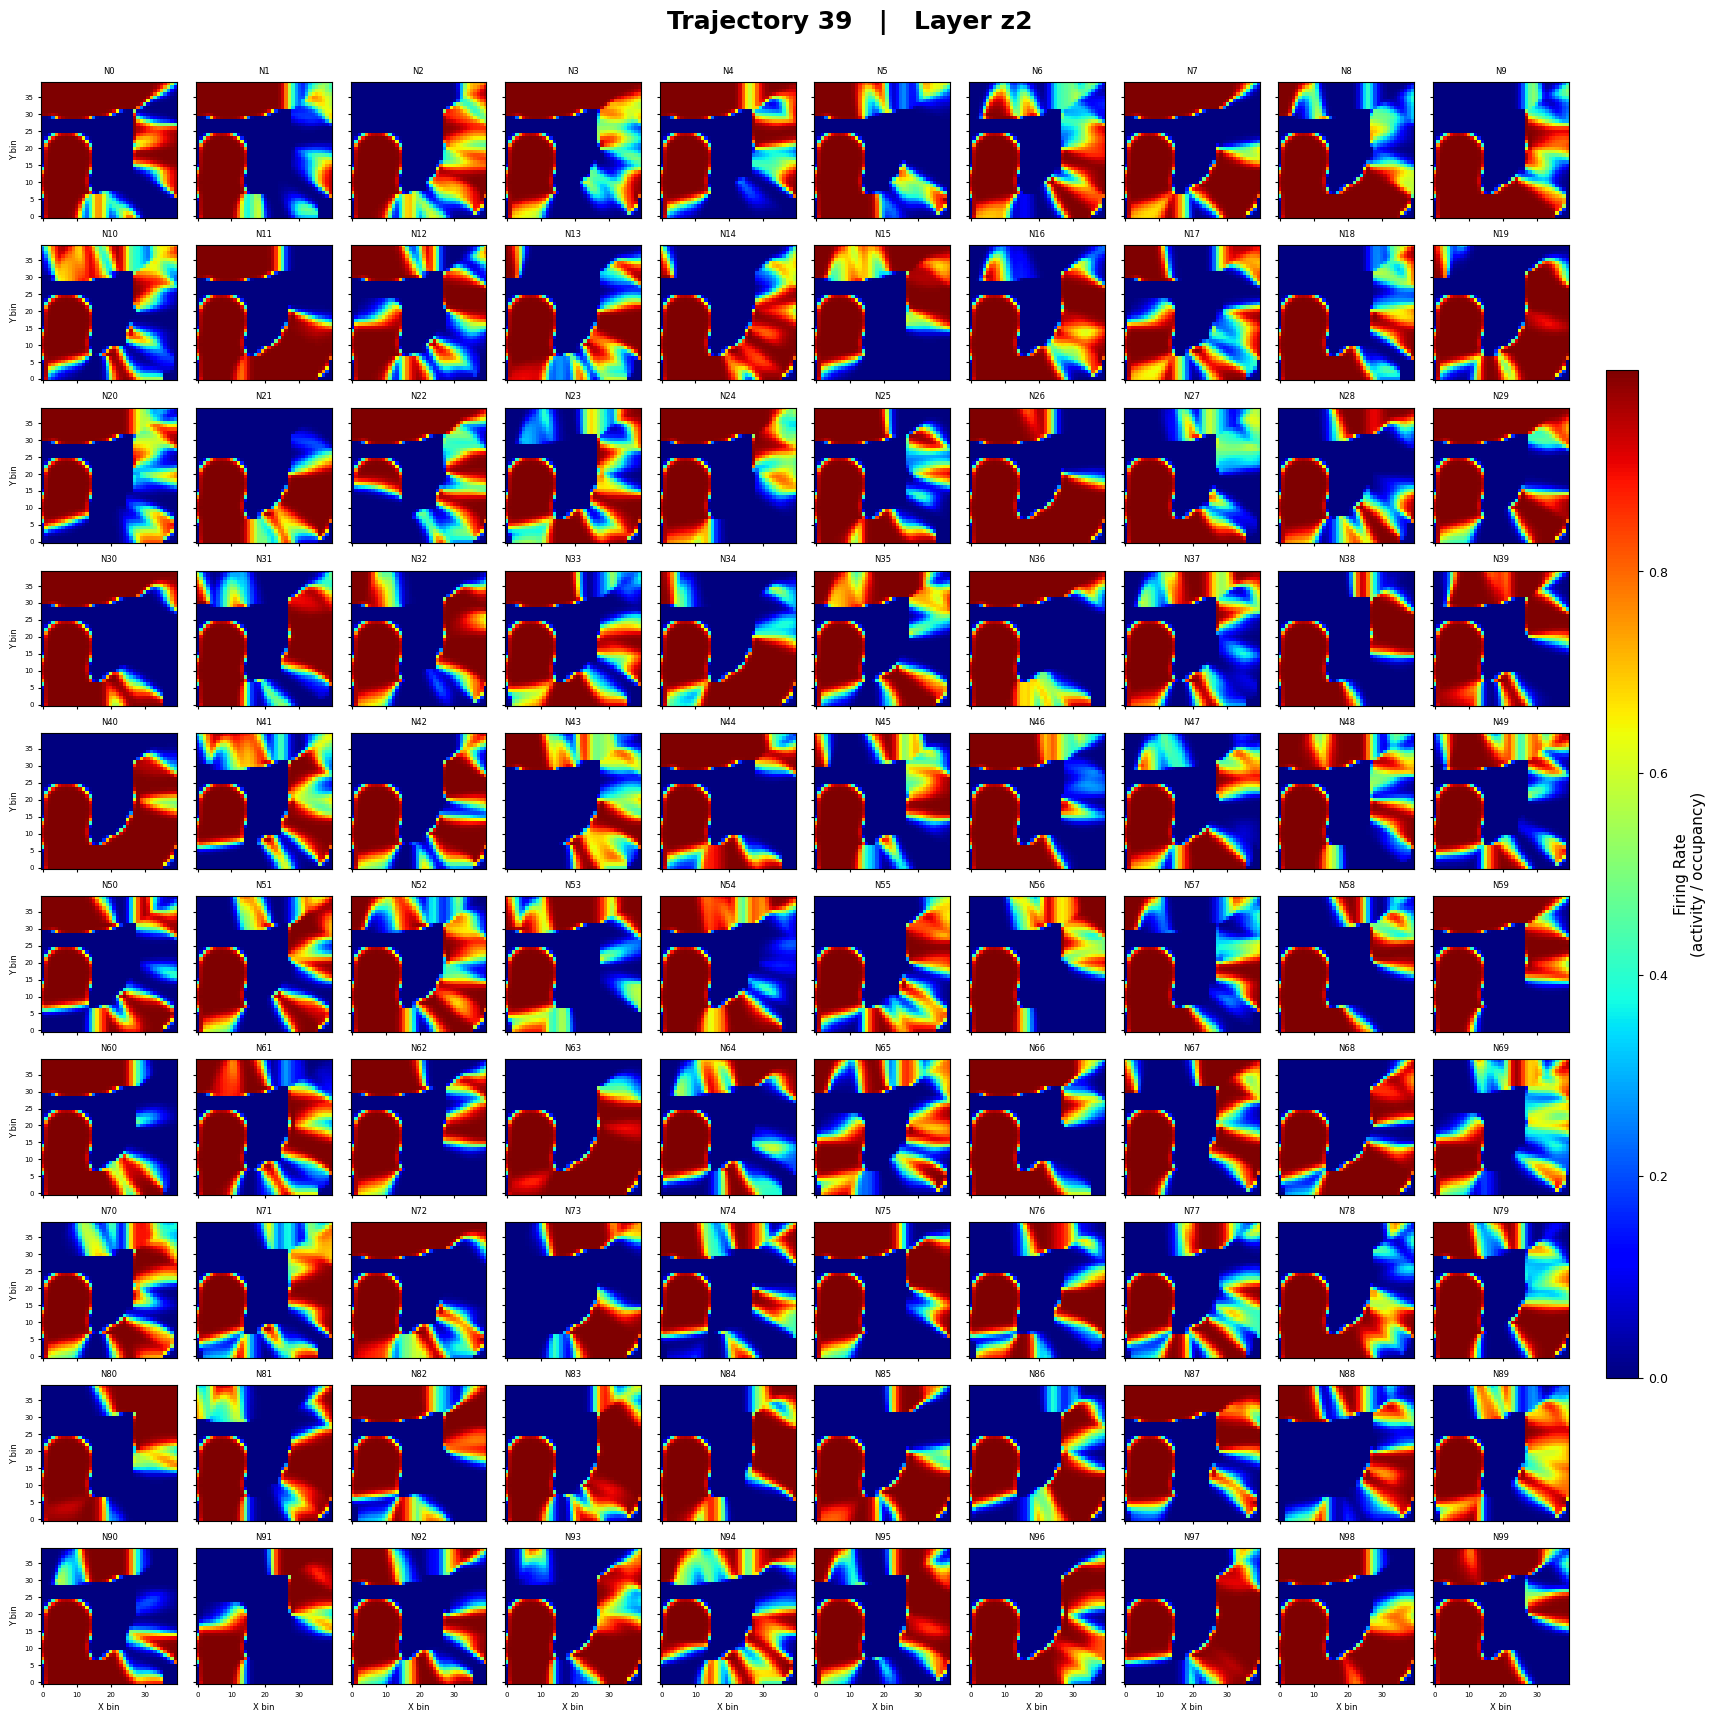

Plotting d3...


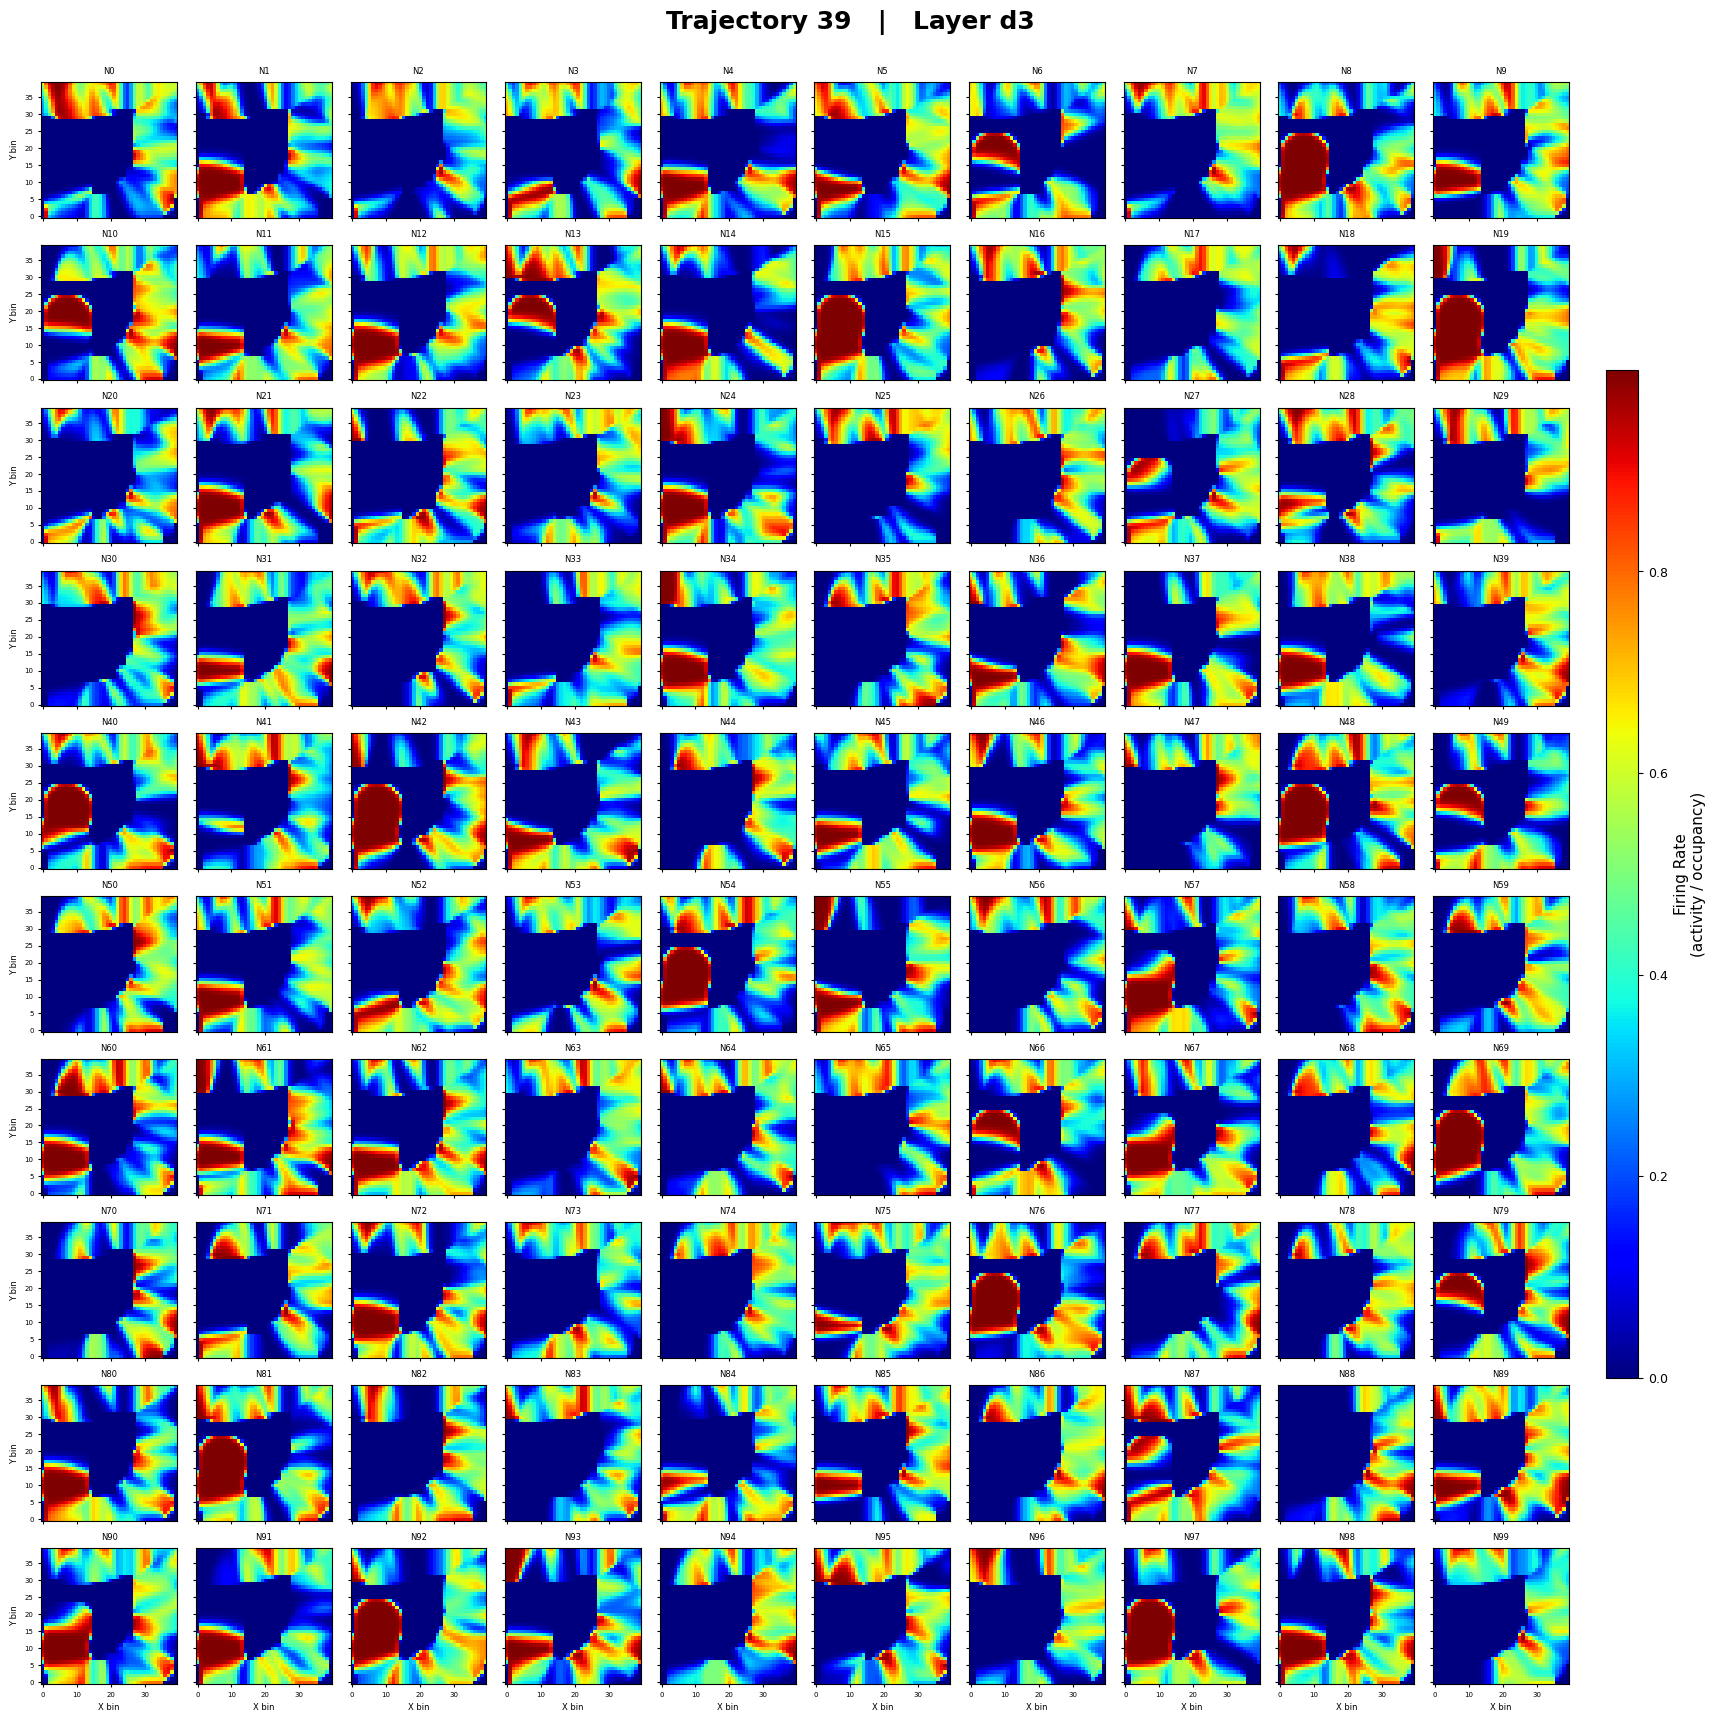

Plotting z3...


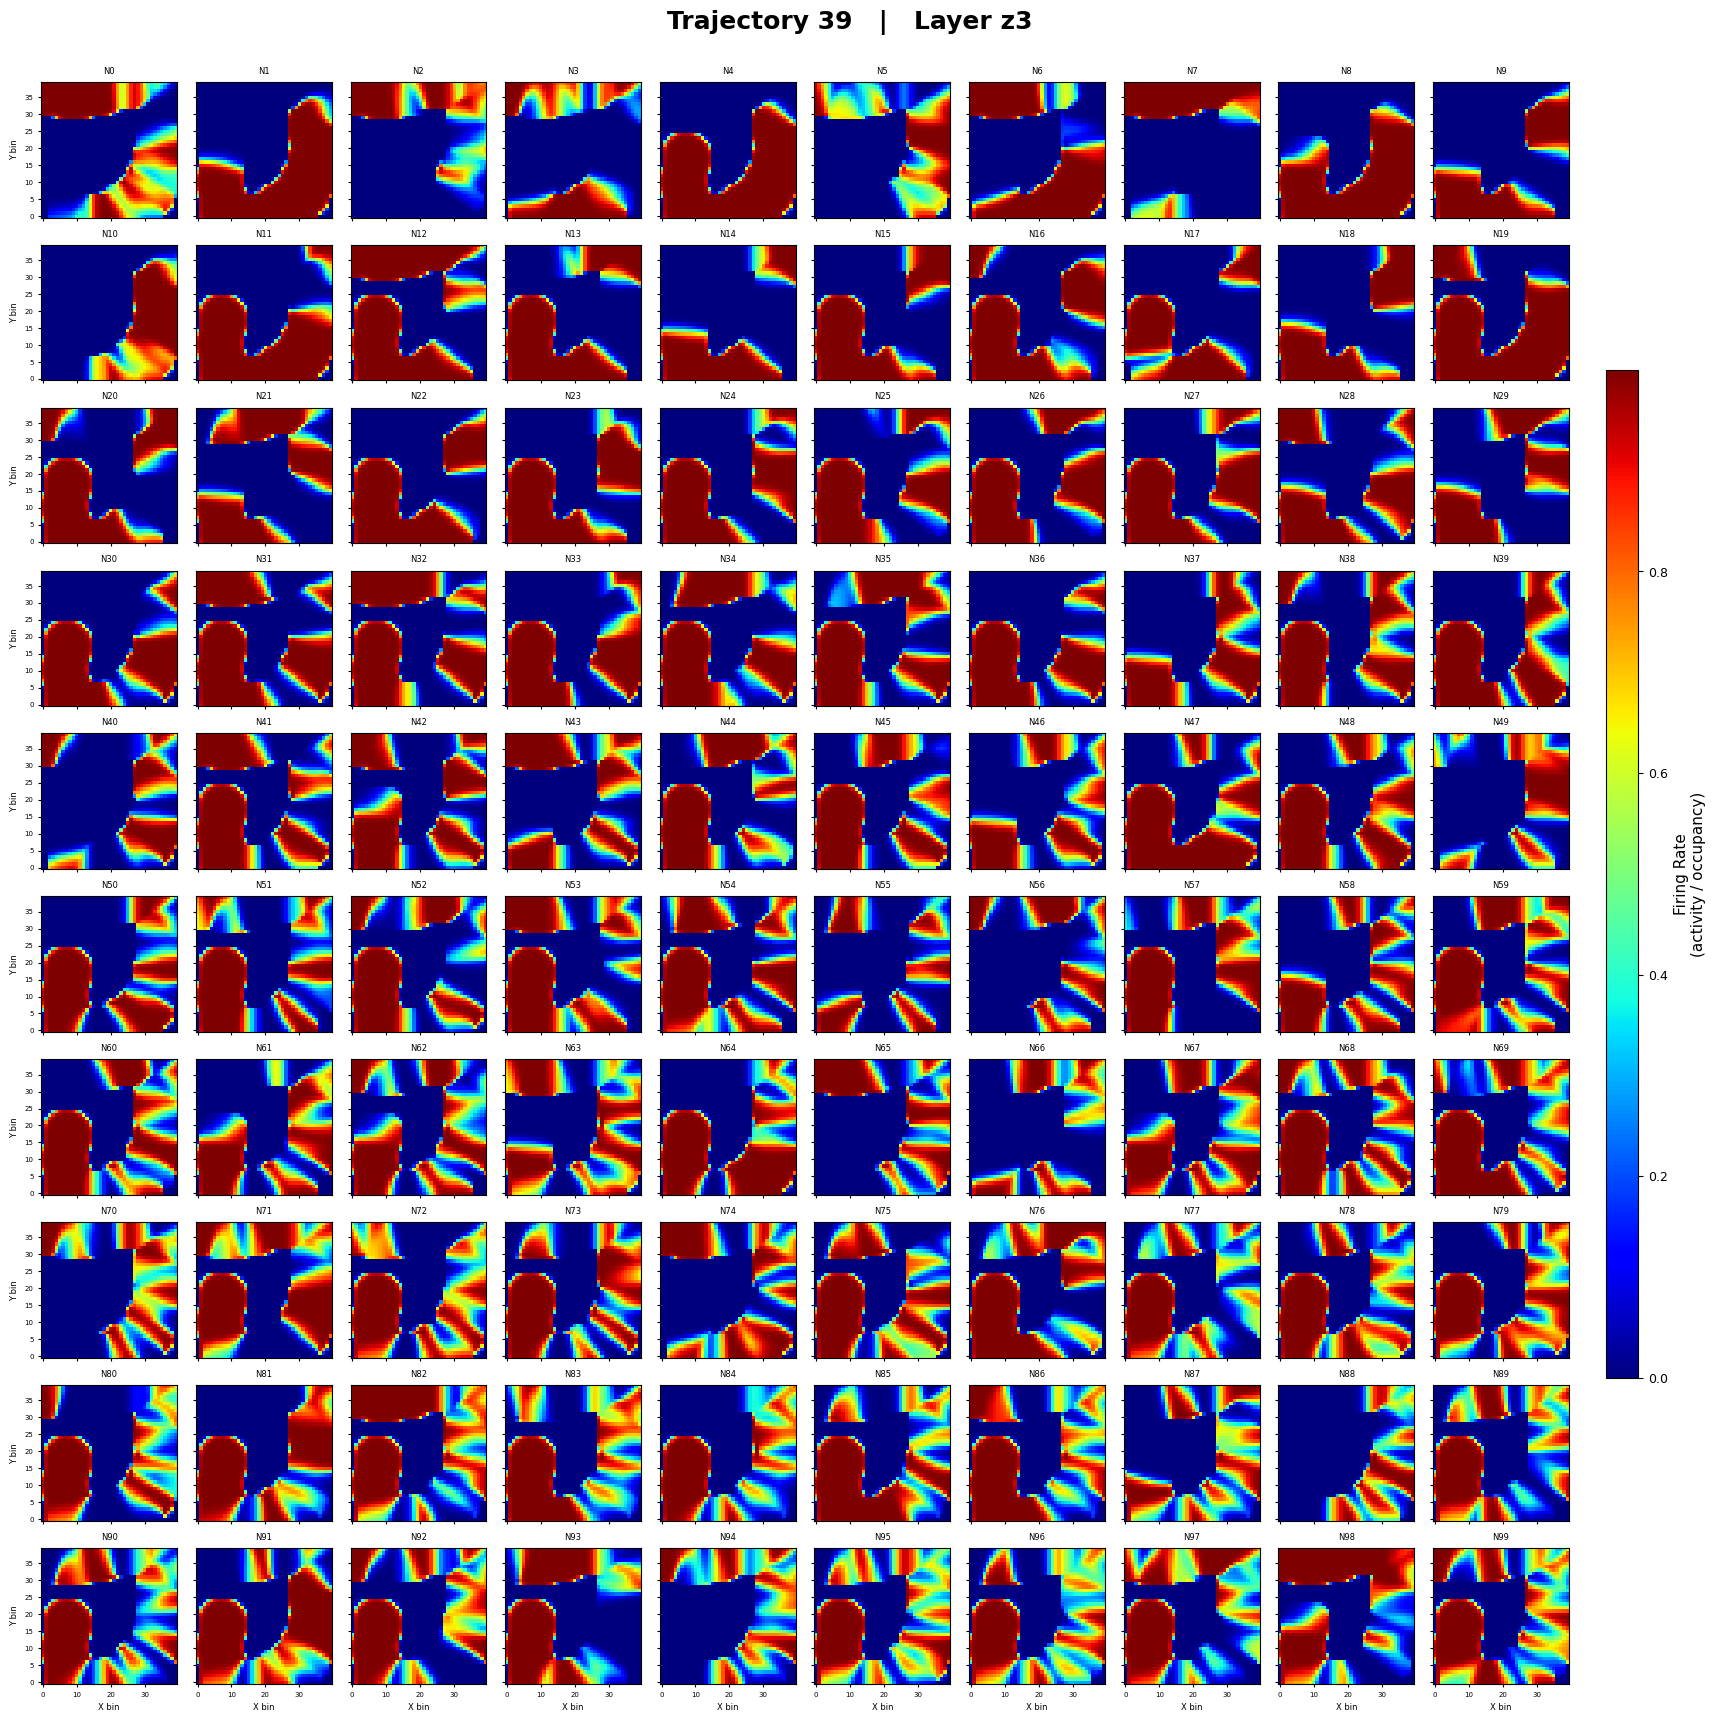

Plotting d4...


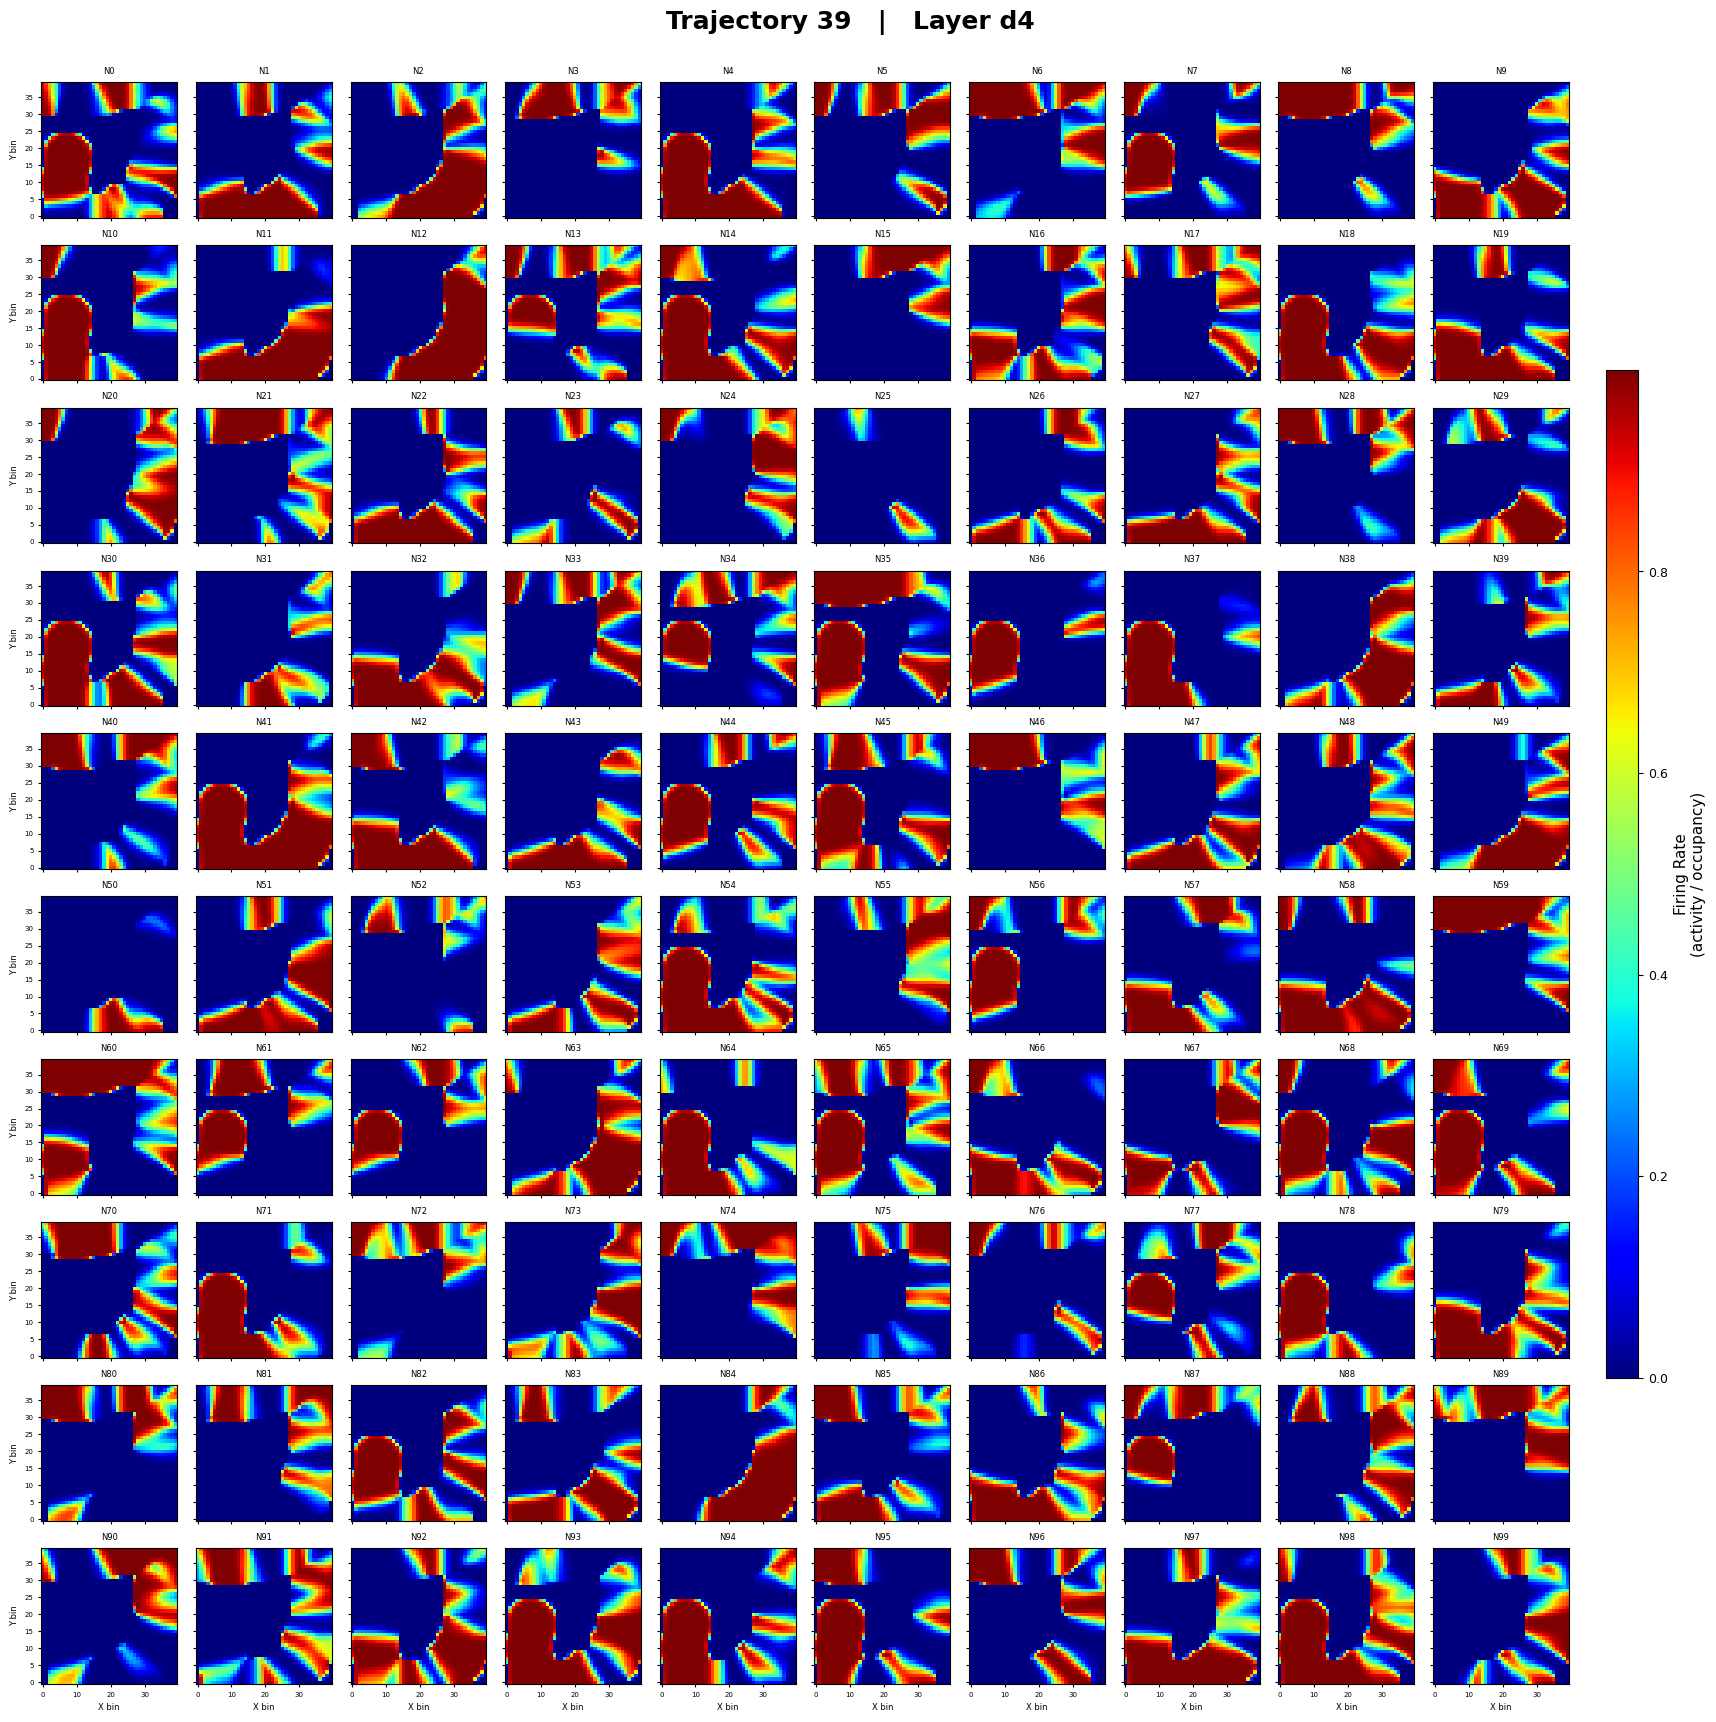



Trajectory 30


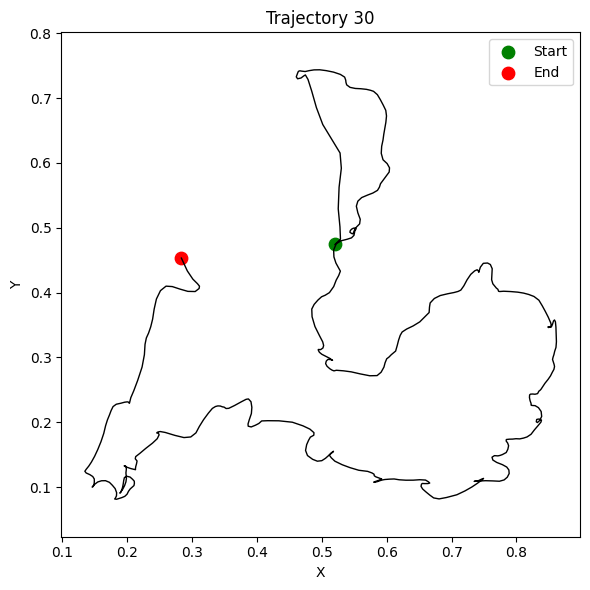

Plotting d1...


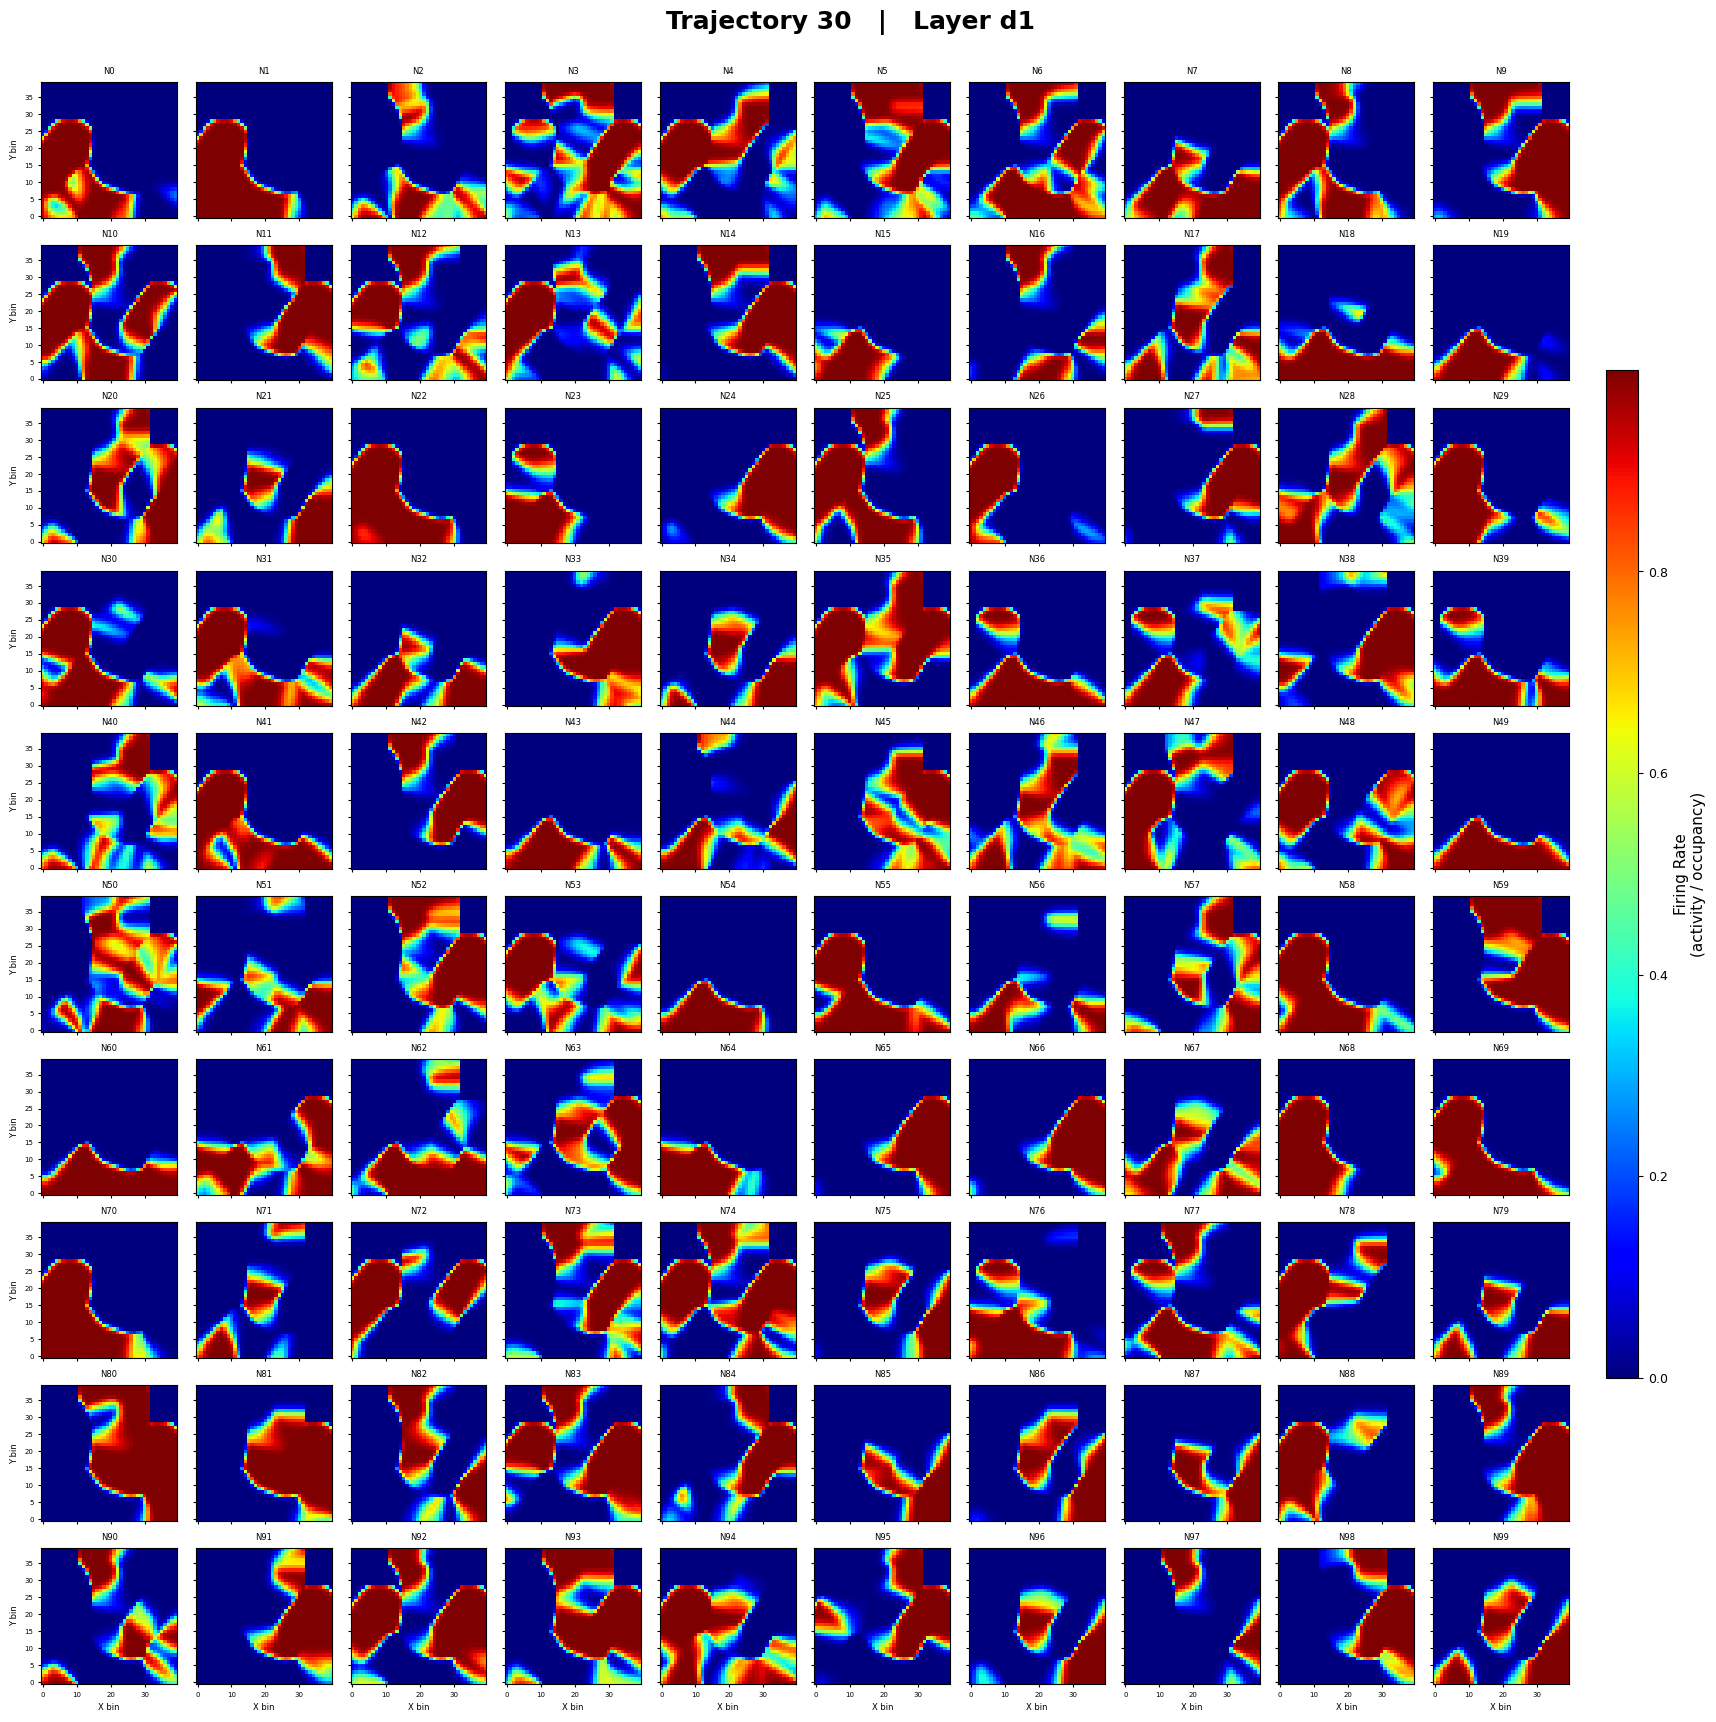

Plotting z1...


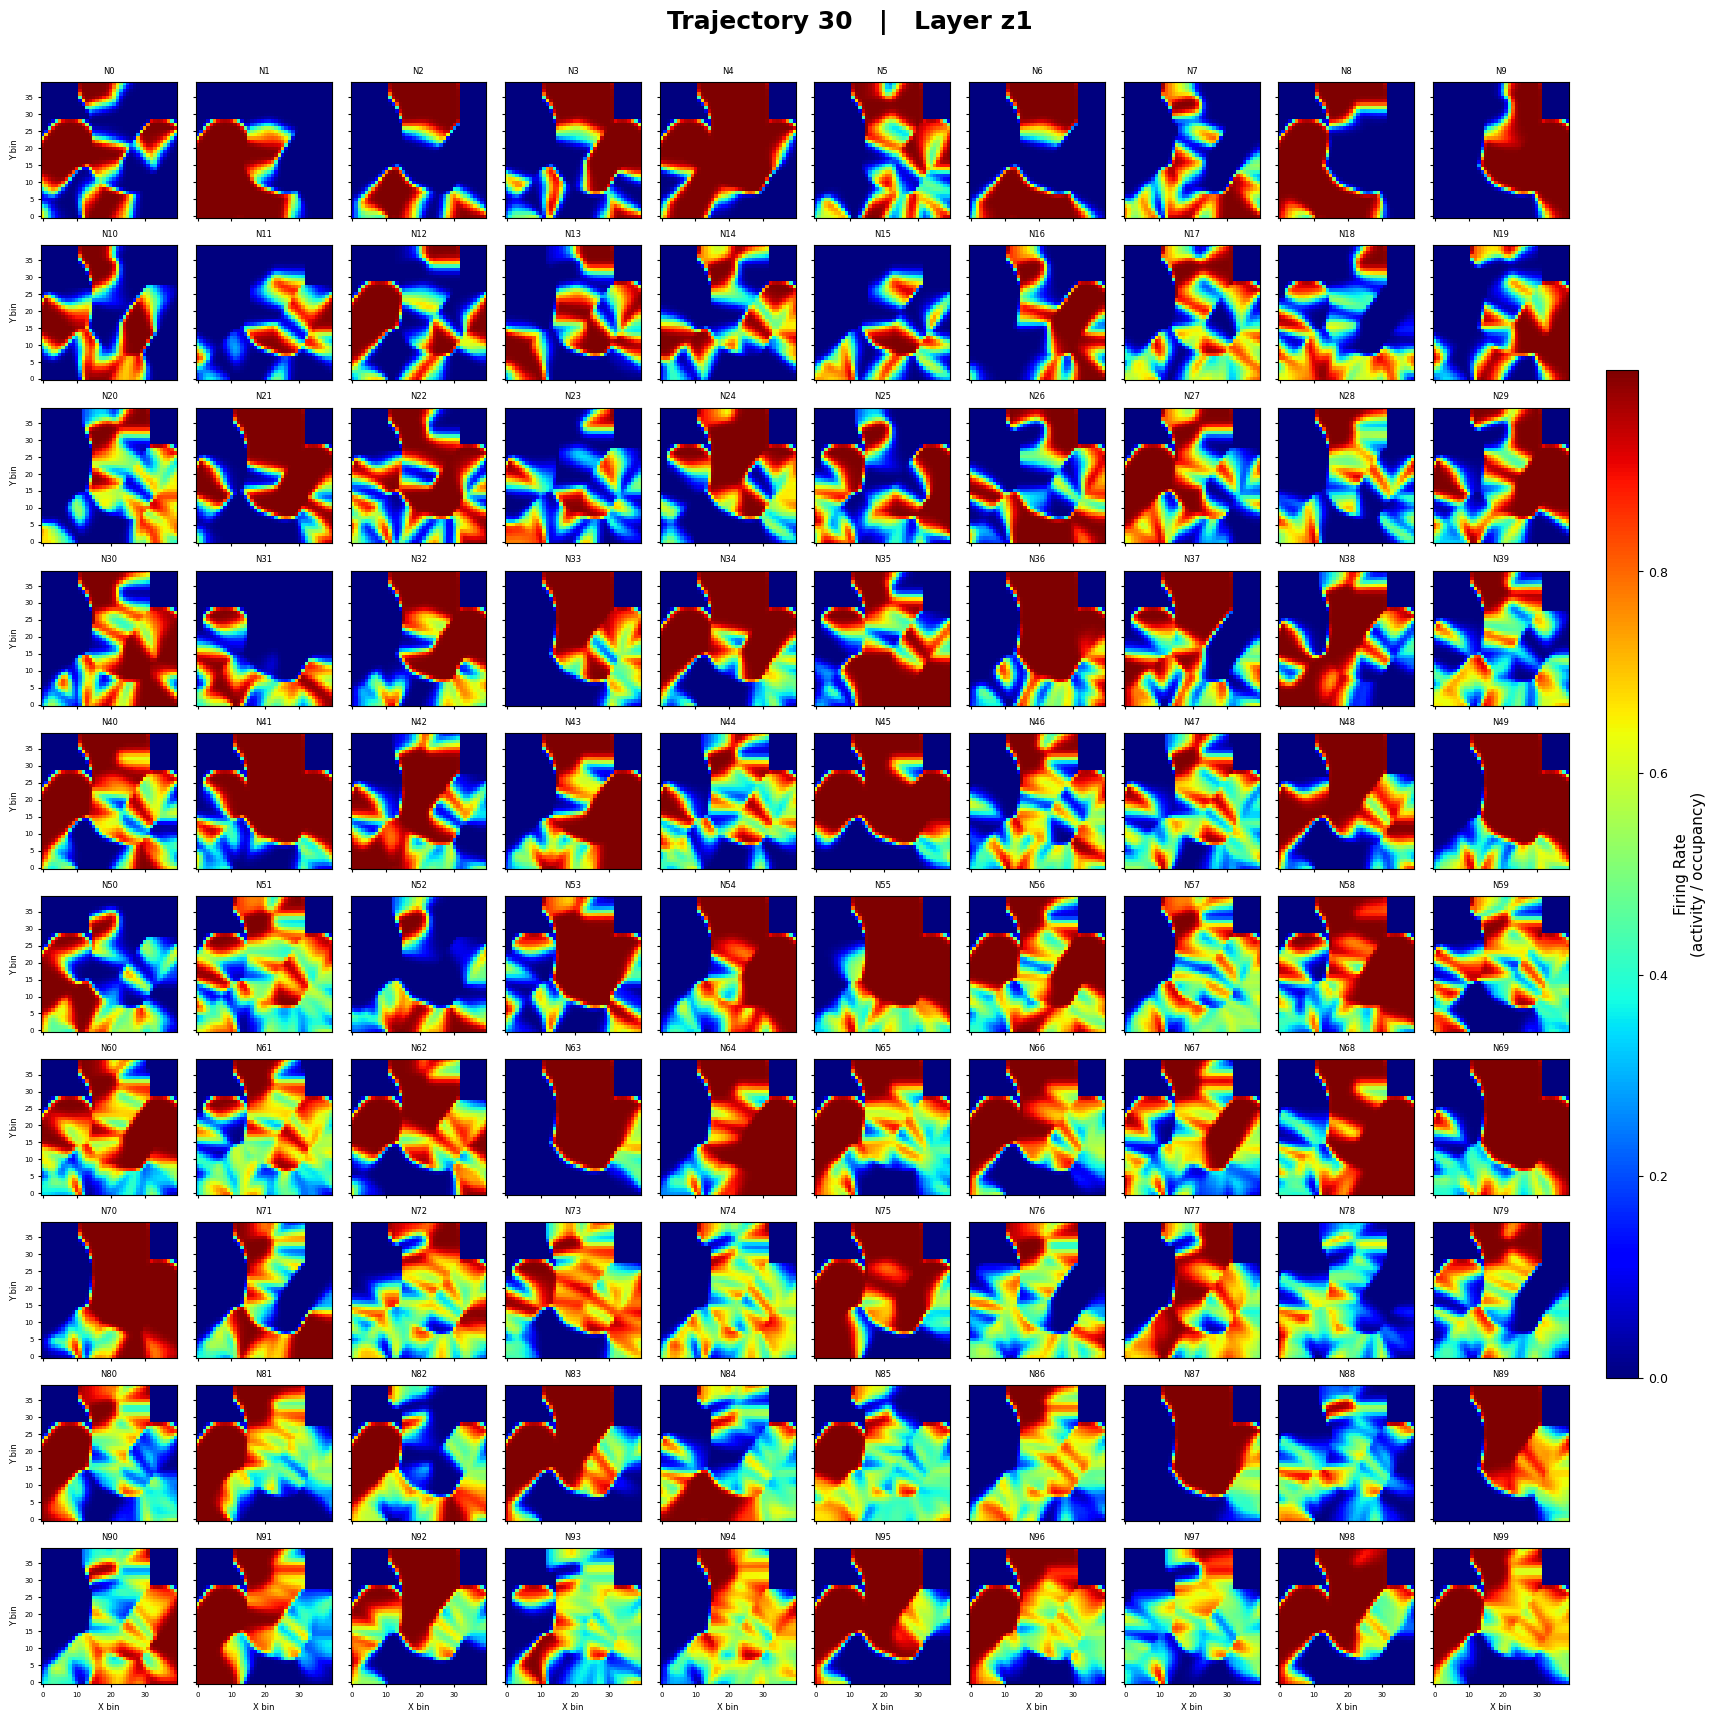

Plotting d2...


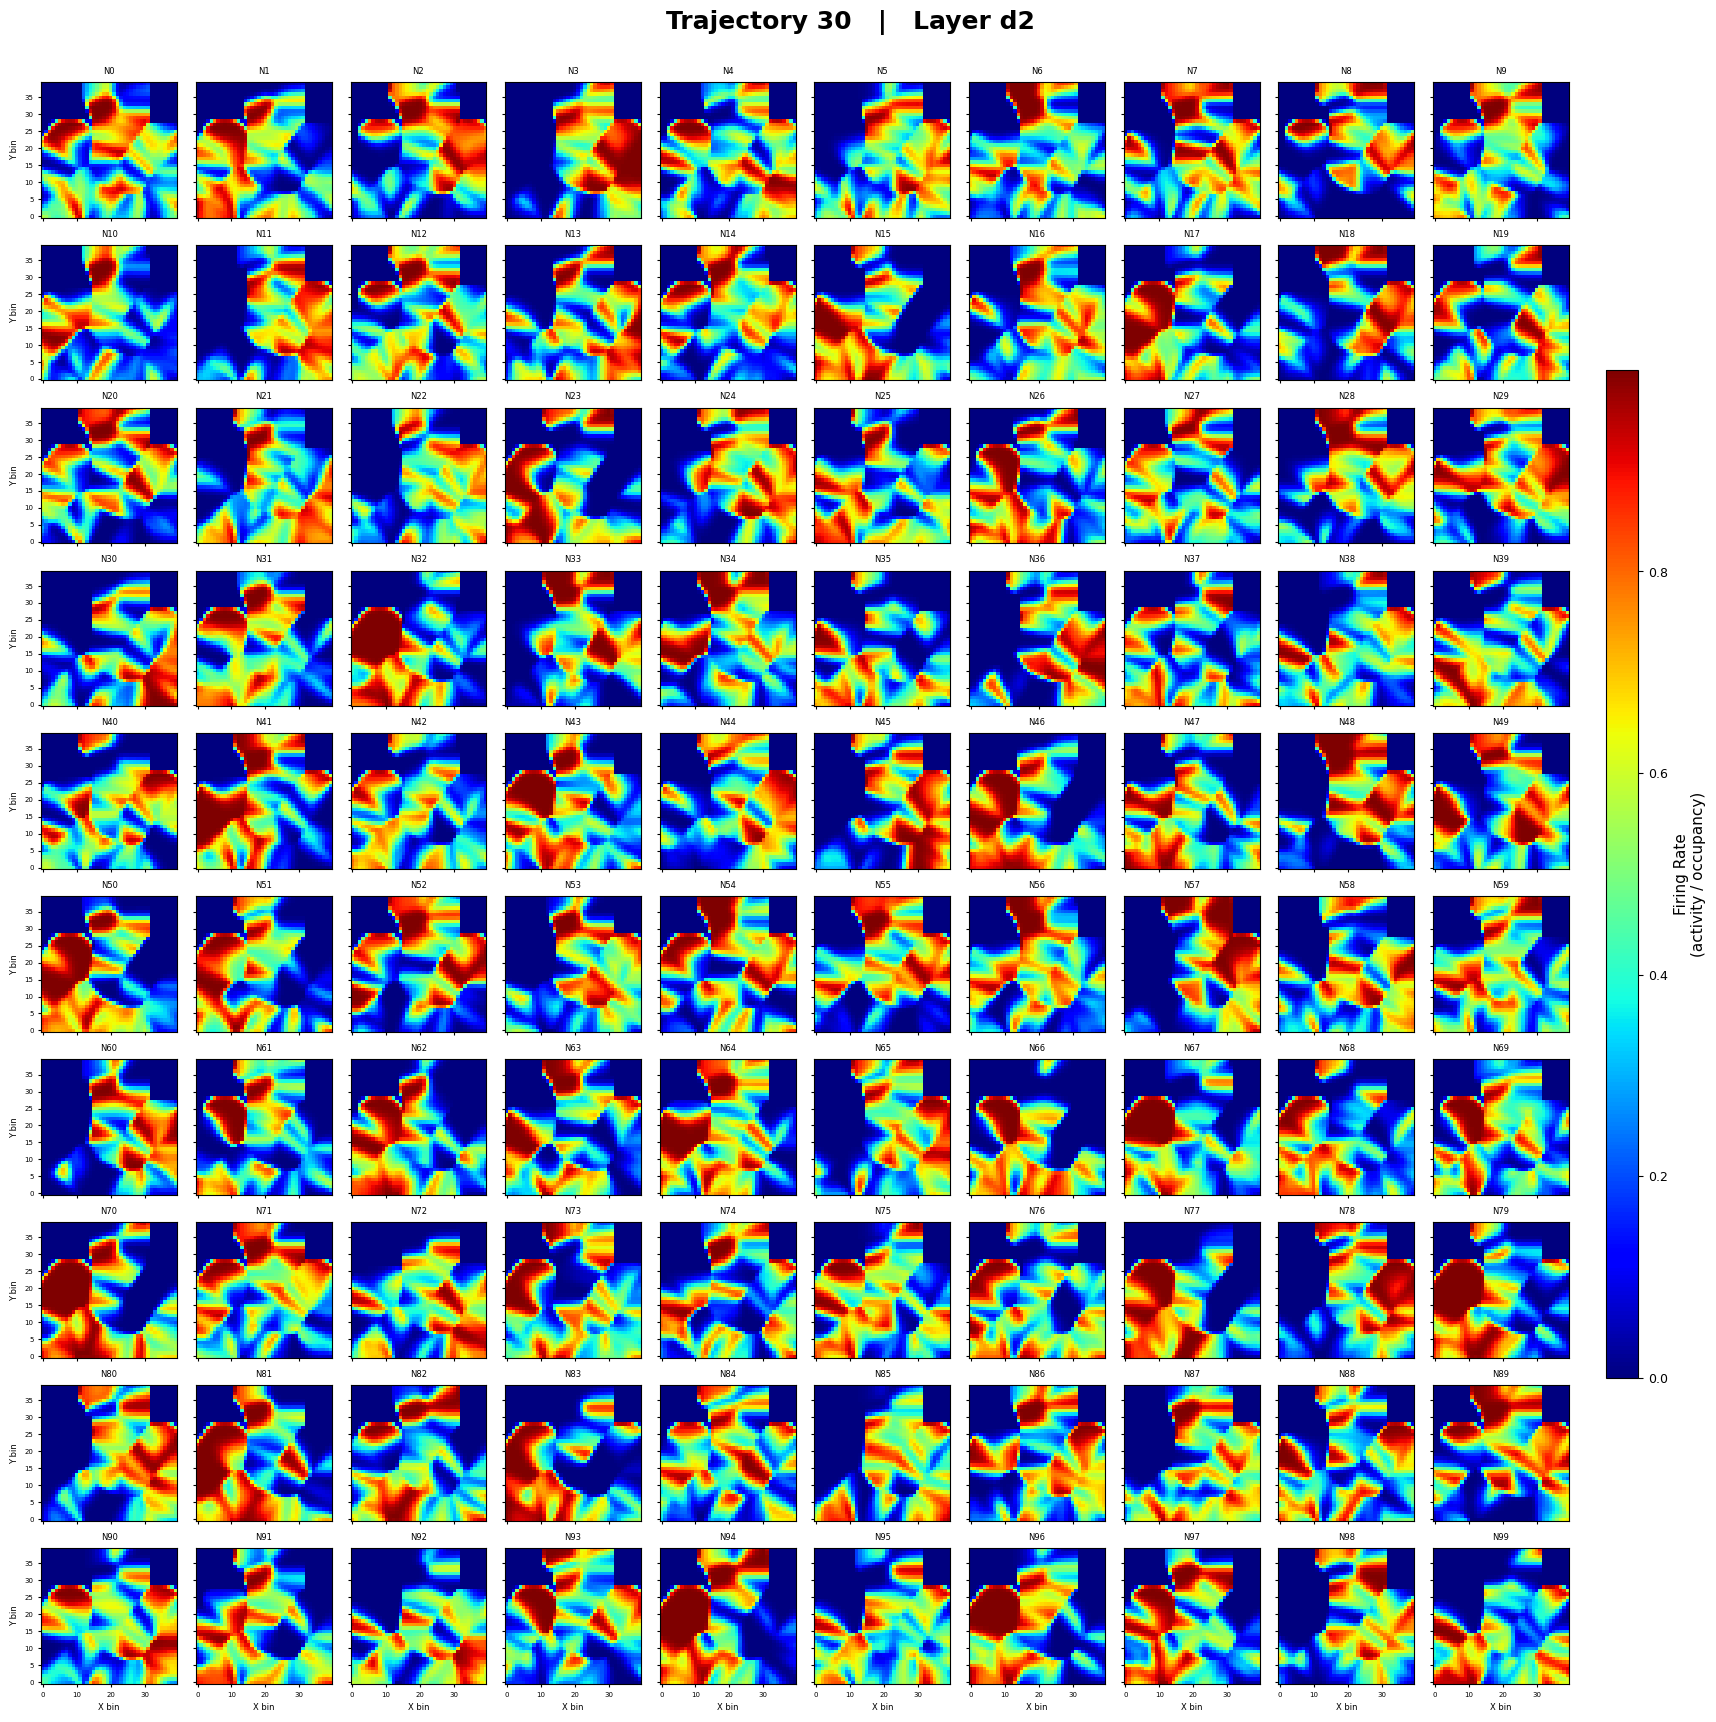

Plotting z2...


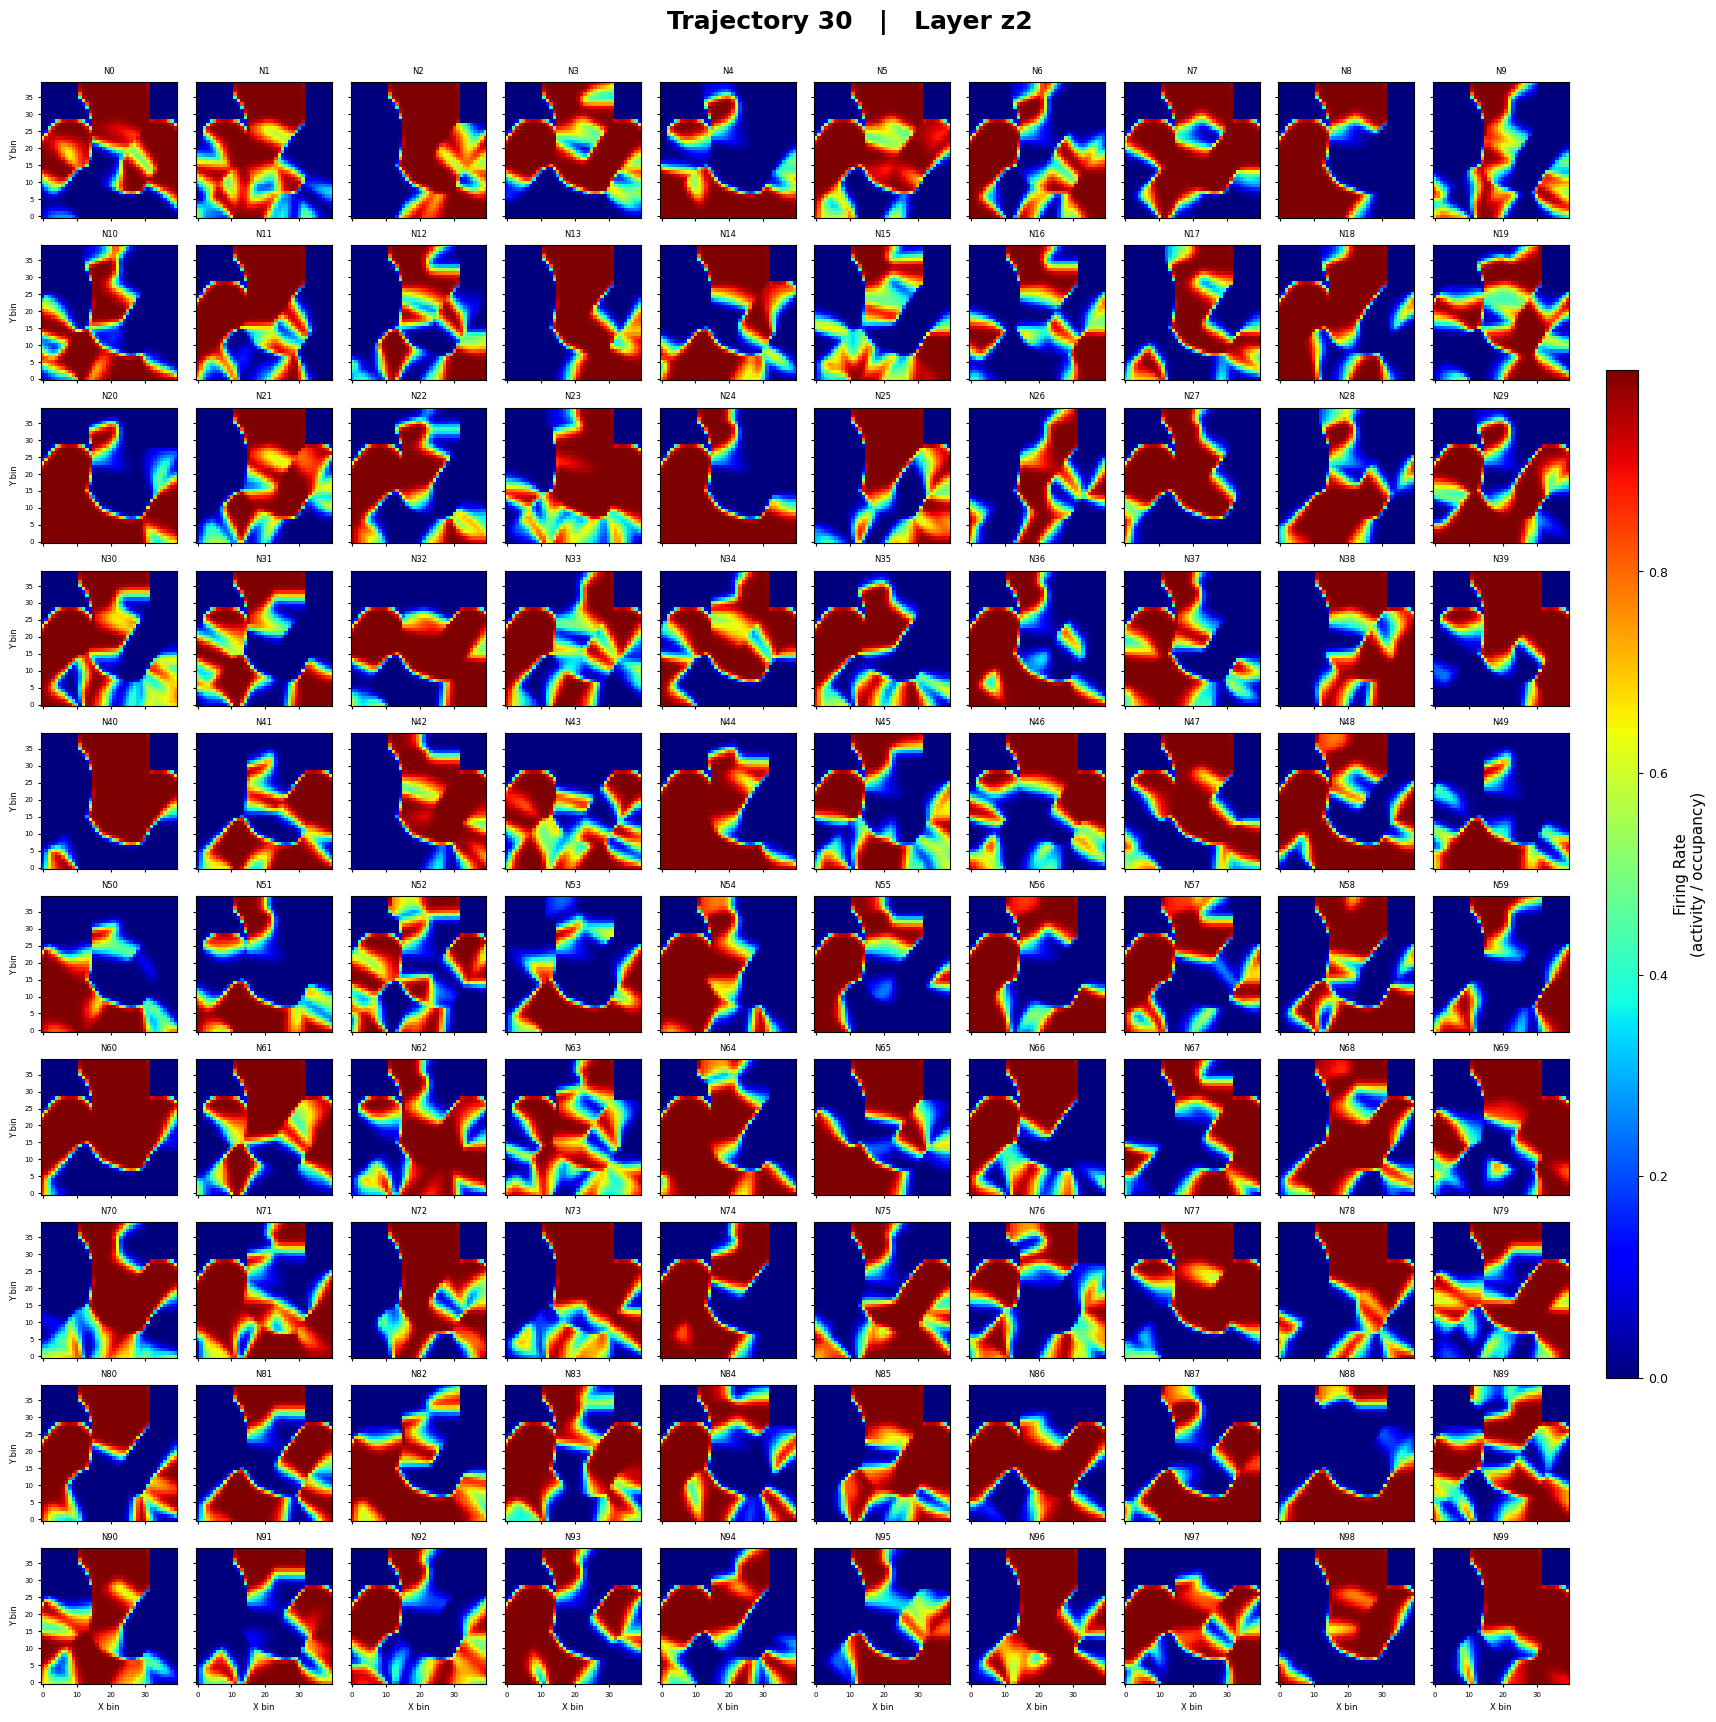

Plotting d3...


In [ ]:
layers = [
    "d1",
    "z1",
    "d2",
    "z2",
    "d3",
    "z3",
    "d4"
]

for traj in random_trajs:

    print("\n")
    print("="*80)
    print(f"Trajectory {traj}")
    print("="*80)

    # Plot trajectory
    plot_trajectory(traj)

    # Plot every layer
    for layer in layers:

        print(f"Plotting {layer}...")

        plot_layer(
            traj,
            layer
        )